In [1]:
import os
os.chdir('/workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad')
print(os.listdir('.'))


['-v8-validated-data.md', 'L_Delta_zeros_200_reliable.pkl', 'memory', '.prompts', '.config', 'tau_at_primes_300k.pkl', '.kernel_llm_logs_1.txt', 'weil_modular.py']


In [2]:
import pickle
with open('L_Delta_zeros_200_reliable.pkl','rb') as f:
 zeros = pickle.load(f)
print(type(zeros), len(zeros) if hasattr(zeros,'__len__') else 'n/a')
print(zeros[:3] if hasattr(zeros,'__getitem__') else zeros)


<class 'list'> 61
[mpc(real='0.5', imag='9.2223793999211025'), mpc(real='0.5', imag='13.907549861392134'), mpc(real='0.5', imag='17.442776978234473')]


In [3]:
with open('tau_at_primes_300k.pkl','rb') as f:
 tau300k = pickle.load(f)
print(type(tau300k), len(tau300k))
# sample first 3
import itertools
print(list(itertools.islice(tau300k.items(), 3)))
print('max key:', max(tau300k.keys()))


<class 'dict'> 25997
[(2, -24), (3, 252), (5, 4830)]
max key: 299993


In [4]:
import sys
# Try to find weil_quadratic_form_general anywhere
import subprocess
out = subprocess.run(['find', '/', '-name', 'weil_quadratic_form_general*', '-not', '-path', '/proc/*', '-not', '-path', '/sys/*'], capture_output=True, text=True, timeout=60)
print('STDOUT:', out.stdout)
print('STDERR:', out.stderr[:500])


STDOUT: 
STDERR: find: ‘/app’: Permission denied
find: ‘/etc/cron.d’: Permission denied
find: ‘/etc/ssh’: Permission denied
find: ‘/etc/polkit-1/rules.d’: Permission denied
find: ‘/etc/ssl/private’: Permission denied
find: ‘/proc/1/fd’: Permission denied
find: ‘/proc/1/task/1/fd’: Permission denied
find: ‘/proc/1/task/1/ns’: Permission denied
find: ‘/proc/1/task/2/fd’: Permission denied
find: ‘/proc/1/task/2/ns’: Permission denied
find: ‘/proc/1/task/3/fd’: Permission denied
find: ‘/proc/1/task/3/ns’: Permission


In [5]:
out = subprocess.run(['find', '/workspace', '-name', '*.py', '-type', 'f'], capture_output=True, text=True, timeout=60)
print(out.stdout)


/workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad/.config/ipython/profile_default/ipython_kernel_config.py
/workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad/.config/ipython/profile_default/heron_matplotlib_theme.py
/workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad/.config/ipython/profile_default/startup/01-ssl-strict-workaround.py
/workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad/.config/ipython/profile_default/startup/00-heron-matplotlib.py
/workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad/weil_modular.py



In [6]:
import sys
# Check if weil_quadratic_form_general is importable from anywhere
try:
 import weil_quadratic_form_general as wqfg
 print("Found:", wqfg.__file__)
 print(dir(wqfg))
except Exception as e:
 print("Not directly importable:", e)
# Try sys.path
print(sys.path)


Not directly importable: No module named 'weil_quadratic_form_general'
['', '/app/kernel_env/lib/python3.13/site-packages', '/app/python/cpython-3.13.7-linux-x86_64-gnu/lib/python313.zip', '/app/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13', '/app/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/lib-dynload', '/workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad']


In [7]:
import os
ls = subprocess.run(['ls','-la','memory'], capture_output=True, text=True)
print(ls.stdout)
ls2 = subprocess.run(['ls','-la','.prompts'], capture_output=True, text=True)
print(ls2.stdout)


total 97
drwxr-sr-x 2 root jupytergroup 4096 Jun 1 07:19 .
drwxrwsr-x 5 root jupytergroup 4096 Jun 1 07:19 ..
-rw-r--r-- 1 root jupytergroup 90139 Jun 1 07:27 5a3135cd-f330-4f0c-9cbf-5f1c64e40aad_memory_heron_c0_20260601T071901936636.jsonl

total 15
drwxrwsr-x 2 root jupytergroup 4096 Jun 1 07:19 .
drwxrwsr-x 5 root jupytergroup 4096 Jun 1 07:19 ..
-rw-rw-r-- 1 root jupytergroup 3909 Jun 1 07:19 BOOTSTRAP.md
-rw-rw-r-- 1 root jupytergroup 1997 Jun 1 07:19 HEARTBEAT.md
-rw-rw-r-- 1 root jupytergroup 319 Jun 1 07:19 MEMORY.md



In [8]:
out = subprocess.run(['grep','-l','_phi_at_points\|weil_quadratic_form_general\|_g_at_u','-r','/'], capture_output=True, text=True, timeout=120)
print('found:', out.stdout[:3000])


<>:1: SyntaxWarning: invalid escape sequence '\|'
<>:1: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_20/1053684177.py:1: SyntaxWarning: invalid escape sequence '\|'
 out = subprocess.run(['grep','-l','_phi_at_points\|weil_quadratic_form_general\|_g_at_u','-r','/'], capture_output=True, text=True, timeout=120)


found: /proc/309/cmdline
/proc/309/task/309/cmdline
/workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad/memory/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad_memory_heron_c0_20260601T071901936636.jsonl
/workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad/weil_modular.py



In [9]:
# Check the memory JSONL for any prior writes
import json
mem_path = 'memory/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad_memory_heron_c0_20260601T071901936636.jsonl'
with open(mem_path) as f:
 lines = f.readlines()
print('Lines:', len(lines))
# Search for _phi_at_points definition
hits = []
for i, l in enumerate(lines):
 if '_phi_at_points' in l or '_g_at_u' in l or 'def _phi' in l or 'def _g_at' in l:
 hits.append(i)
print('Hits:', hits)


Lines: 31
Hits: [3, 11, 12, 13, 14, 15, 21, 28, 29, 30]


In [10]:
for i in [11,12,13,14,15,21,28,29,30]:
 rec = json.loads(lines[i])
 print(f"--- Line {i} role={rec.get('role','?')} type={rec.get('type','?')} ---")
 content = rec.get('content','')
 if isinstance(content, list):
 for c in content:
 if isinstance(c, dict):
 t = c.get('text','') or c.get('content','')
 if 'def _phi' in t or 'def _g_at' in t or '_phi_at_points' in t:
 print(t[:3500])
 print('...(snip)...')
 break
 elif isinstance(content, str):
 if 'def _phi' in content or 'def _g_at' in content:
 print(content[:3500])


--- Line 11 role=? type=? ---
--- Line 12 role=? type=? ---
--- Line 13 role=? type=? ---
--- Line 14 role=? type=? ---
--- Line 15 role=? type=? ---
--- Line 21 role=? type=? ---
--- Line 28 role=? type=? ---
--- Line 29 role=? type=? ---
--- Line 30 role=? type=? ---


In [11]:
rec = json.loads(lines[11])
print(list(rec.keys()))
print(json.dumps(rec, indent=2)[:2000])


['ts', 'step', 'compaction_occurred', 'message']
{
 "ts": "2026-06-01T07:19:35.998919+00:00",
 "step": 5,
 "compaction_occurred": false,
 "message": {
 "role": "tool",
 "content": " 1\u2192\"\"\"\n 2\u2192Extension of weil_quadratic_form_general.py to support modular L-functions L(f, s)\n 3\u2192for weight-k level-1 holomorphic cusp forms (e.g. Ramanujan \u0394, k=12).\n 4\u2192\n 5\u2192Analytic normalization: critical line Re(s)=1/2; Dirichlet coefficients\n 6\u2192 a_f(n) = c_f(n) / n^{(k-1)/2}, with c_f the unnormalized arithmetic coefficients.\n 7\u2192For \u0394: c_\u0394(n) = \u03c4(n), so a_\u0394(n) = \u03c4(n)/n^{11/2}, |a_\u0394(p)| \u2264 2 (Deligne).\n 8\u2192\n 9\u2192Explicit formula for L(\u0394, s) (degree 2, conductor 1, no pole, \u0393_C(s + 11/2)):\n 10\u2192 \u03a3_\u03c1 h(\u03b3) = (1/2\u03c0) \u222b h(r) [-2 log(2\u03c0) + 2 Re \u03c8(6 + ir)] dr\n 11\u2192 - 2 \u03a3_{p^k} (\u03b1_p^k + \u03b2_p^k) log(p) / p^{k/2} \u00b7 g(k log p)\n 12\u2192where \u03b1_p + \

In [12]:
# Inspect all msgs to see if the engine source ever was written
for i, l in enumerate(lines):
 rec = json.loads(l)
 msg = rec.get('message',{})
 role = msg.get('role','?')
 c = msg.get('content','')
 if isinstance(c,list):
 for item in c:
 t = item.get('text', item.get('content','')) if isinstance(item,dict) else str(item)
 if 'def _phi_at_points' in t or 'def _g_at_u' in t:
 print(f"line {i}: FOUND DEF")
 print(t[:3000])
 elif isinstance(c,str):
 if 'def _phi_at_points' in c or 'def _g_at_u' in c:
 print(f"line {i}: FOUND DEF (str)")
 print(c[:3000])
print("done scan")


done scan


In [13]:
# The engine module source is not available. We must implement _phi_at_points and _g_at_u faithfully
# from the spec / structure. Let's first scan all msgs for any code that might define these or run compute_Q
for i, l in enumerate(lines):
 rec = json.loads(l)
 msg = rec.get('message',{})
 role = msg.get('role','?')
 c = msg.get('content','')
 text = c if isinstance(c,str) else json.dumps(c)
 short = text[:200].replace('\n',' ')
 print(f"L{i} step={rec.get('step')} role={role} len={len(text)} | {short}")


L0 step=1 role=system len=11003 | You are a rigorous data analysis agent with deep expertise in statistics, data science, and quantitative methods. Your primary directive is to provide accurate, evidence-based analysis in Jupyter not
L1 step=1 role=user len=16833 | <message-metadata /> ## e14c Code Reference Your environment includes the `e14c` Python library, which contains code that may be useful for your task. Use the `view_docs` tool to view detailed documen
L2 step=1 role=user len=73 | <message-metadata /> pwd: /workspace/5a3135cd-f330-4f0c-9cbf-5f1c64e40aad
L3 step=1 role=user len=6260 | <message-metadata /> Here is some information on the dataset you will be analyzing: <primary-dataset-description> The primary dataset is a single authoritative reference markdown specification file, 
L4 step=1 role=assistant len=4 | null
L5 step=2 role=tool len=198 | [Appended Cell #0] [stdout] ['-v8-validated-data.md', 'L_Delta_zeros_200_reliable.pkl', 'memory', '.prompts', '.config', 'tau_at_pr

In [14]:
# The engine source isn't available. We must implement _phi_at_points and _g_at_u
# from the documented specification, validated by sanity checks.
# 
# From -v8 §3 and weil_modular.py docstrings/comments:
# - Hermite-Gauss basis: φ_j(t) = H_j((t-T0)/σ) * exp(-((t-T0)/σ)²/2) / sqrt(σ √π · 2^j · j!)
# (the σ factor in the normalization makes ∫ φ_i φ_j dt = δ_ij)
# - g_ij(u) = ∫ φ_i(t) φ_j(t) e^{i u t} dt
#
# Validation test: for L(Δ,s) using the X=3×10^5 tau and our 61 zeros, η should be close
# to "few × 10^{-3}" or whatever value gives "super-polynomial decay" toward 10^{-12} by 10^7.
# More importantly: try compute_Q for the Riemann ζ (where M_zeros is built from many zeros)
# and confirm η matches the spec's noise floor of 1e-8 to 1e-10.
#
# But first: let's investigate the normalization carefully. M_arch uses:
# exp_neg_norm = exp(-norm[i]-norm[j] - 0.5*log(π)) = 1/√(π · 2^(i+j) · i! · j!)
# and then is multiplied with (Σ w_n H_i(x_n) H_j(x_n) ψ_vals_n) / (2π).
# Gauss-Hermite quadrature: ∫ f(x) e^{-x²} dx ≈ Σ w_n f(x_n).
# 
# So: M_arch_ij ≈ ∫ H_i(x) H_j(x) e^{-x²} · ψ_vals(x) dx / √(π · 2^(i+j) · i! · j!) / (2π)
# = ∫ φ̂_i(x) φ̂_j(x) · ψ_vals(x) dx / (2π)
# where φ̂_j(x) = H_j(x) e^{-x²/2} / √(√π · 2^j · j!) is the orthonormal-in-L²(R) Hermite function,
# and x is the *quadrature* variable, NOT the t-variable. The relation x = (t-T0)/σ implies
# dt = σ dx, hence φ_j(t) = (1/√σ) φ̂_j((t-T0)/σ) for L²(dt) orthonormality.
#
# In the arch term, the original integral over r is (1/(2π)) ∫ h(r) Φ(r) dr where h(r) is the
# Fourier transform of g, and h(r) = |∫ φ_i(t)e^{irt} dt|² type stuff. Without seeing the engine
# source, I cannot recover ALL conventions exactly. But the M_zeros expression in the code is
# M_zeros_ij = Σ_n φ_i(γ_n) φ_j(γ_n)
# So the basis is normalized as L²(R, dt) ONB: φ_j(t) = (1/√σ) φ̂_j((t-T0)/σ).
# (Each scaling factor matters because tr(M_zeros) directly enters η.)
#
# Sanity check via simple test: we can run with very small primes_cutoff and large primes
# and verify the trace residual is well-behaved.
#
# Let me reconstruct, then run.

# Implement weil_quadratic_form_general functions:
import numpy as np
from scipy.special import roots_hermite

def _hermite_funcs(x_norm, J):
 """Orthonormal Hermite functions φ̂_j(x) for j=0..J-1 evaluated at x_norm.
 φ̂_j(x) = H_j(x) e^{-x²/2} / sqrt(sqrt(π) 2^j j!)
 Uses stable recursion: ψ_j(x) = sqrt(2/j) x ψ_{j-1}(x) - sqrt((j-1)/j) ψ_{j-2}(x)
 with ψ_0(x) = π^{-1/4} e^{-x²/2}, ψ_1(x) = sqrt(2) x ψ_0(x).
 """
 x_norm = np.asarray(x_norm, dtype=np.float64)
 out = np.zeros((len(x_norm), J), dtype=np.float64)
 out[:, 0] = np.pi**-0.25 * np.exp(-0.5 * x_norm**2)
 if J > 1:
 out[:, 1] = np.sqrt(2.0) * x_norm * out[:, 0]
 for j in range(1, J-1):
 out[:, j+1] = np.sqrt(2.0/(j+1)) * x_norm * out[:, j] - np.sqrt(j/(j+1)) * out[:, j-1]
 return out

def _phi_at_points(t, sigma, T0, J):
 """Return shape (len(t), J) matrix of φ_j(t) where
 φ_j(t) = (1/√σ) φ̂_j((t-T0)/σ)
 is orthonormal in L²(R, dt)."""
 t = np.asarray(t, dtype=np.float64)
 x = (t - T0) / sigma
 psi = _hermite_funcs(x, J)
 return psi / np.sqrt(sigma)

# Quick sanity test: ∫ φ_i(t) φ_j(t) dt = δ_ij
J = 5
t_test = np.linspace(-50, 50, 200000)
dt = t_test[1] - t_test[0]
ph = _phi_at_points(t_test, sigma=1.0, T0=0.0, J=J)
gram = ph.T @ ph * dt
print("Should be approx identity:\n", np.round(gram, 4))


Should be approx identity:
 [[ 1. -0. -0. -0. 0.]
 [-0. 1. -0. -0. 0.]
 [-0. -0. 1. 0. 0.]
 [-0. -0. 0. 1. 0.]
 [ 0. 0. 0. 0. 1.]]


In [15]:
# Good. Now _g_at_u: matrix-valued Fourier transform g_ij(u) = ∫ φ_i(t)φ_j(t) e^{i u t} dt.
# Compute via Gauss-Hermite quadrature in variable x = (t-T0)/σ:
# g_ij(u) = ∫ φ_i(T0+σx) φ_j(T0+σx) e^{i u (T0+σx)} σ dx
# = e^{i u T0} · ∫ (1/σ) φ̂_i(x) φ̂_j(x) e^{i u σ x} σ dx
# = e^{i u T0} · ∫ φ̂_i(x) φ̂_j(x) e^{i u σ x} dx
# = e^{i u T0} · ∫ [H_i(x)H_j(x) e^{-x²}/sqrt(π 2^{i+j} i! j!)] e^{i u σ x} dx
#
# Using Gauss-Hermite quadrature: ∫ f(x) e^{-x²} dx ≈ Σ w_n f(x_n)
# g_ij(u) ≈ e^{i u T0} · Σ_n w_n · H_i(x_n) H_j(x_n) e^{i u σ x_n} / sqrt(π 2^{i+j} i! j!)
#
# Note: weil_modular's M_primes uses _g_at_u and then takes Re part and divides by π.
# For self-dual case (Δ), prime weights c_k(p) are real. The phase e^{i u T0} doesn't drop because
# u = k log p. We take Re part of (weight * g_ij(u)).
# 
# However, there is also typically a "u → -u" symmetry: standard explicit formula has 
# Σ_n Λ(n)/√n · [g(log n) + ḡ(log n)] for self-dual (or just 2 Re g(log n)).
# weil_modular.py inserts -2 Σ_{p^k} ... g(k log p), and M_primes_ij = Re[Σ w_n g_ij(log n)] / π.
# 
# The factor of -2 is missing in code; instead the symmetric form likely absorbs it.
# Actually: include_negative_zeros doubles M_zeros (each γ + -γ contributes equally), so
# tr(M_zeros) is "doubled". On the arith side, M_arch is already computed with 2 Re ψ
# (counting both ±γ); M_polar doesn't double. M_primes... if we only include u = +k log p
# but the basis evaluation includes Re part, then Re g(u) is symmetric in u→-u for real basis,
# so single sum × Re effectively captures the symmetric part.
#
# Let me verify the relation by running for the Riemann ζ control where the convention 
# is expected to give η ≈ 1e-8 to 1e-10. But that requires zeros of zeta — we'd need to compute 5000.
# 
# Better: validate the L(Δ) version directly. Use small X first and see if η decreases with X
# in the expected super-polynomial manner.

from scipy.special import digamma, gammaln, roots_hermite

def _g_at_u(u, sigma, T0, J, n_nodes_quad=200):
 """Return shape (len(u), J, J) array of g_ij(u) = ∫ φ_i(t) φ_j(t) e^{i u t} dt."""
 u = np.asarray(u, dtype=np.float64)
 x, w = roots_hermite(n_nodes_quad)
 # Hermite physicists' polynomial values at x:
 H = np.zeros((J, n_nodes_quad))
 H[0] = 1.0
 if J > 1:
 H[1] = 2 * x
 for n in range(1, J-1):
 H[n+1] = 2 * x * H[n] - 2 * n * H[n-1]
 # Normalization: 1/√(π · 2^{i+j} · i! · j!)
 norm = np.array([0.5*(j*np.log(2) + gammaln(j+1)) for j in range(J)])
 norm_ij = norm[:, None] + norm[None, :] + 0.5*np.log(np.pi) # log of norm
 inv_norm_ij = np.exp(-norm_ij)
 # phase: e^{i u (T0 + σ x_n)}
 # g_ij(u) ≈ Σ_n w_n H_i(x_n) H_j(x_n) e^{i u (T0+σx_n)} · inv_norm_ij
 # Vectorize: for each u, compute Σ_n (w_n · phase_n) · H[i,n] · H[j,n]
 # phase shape (len(u), n_nodes)
 phase = np.exp(1j * u[:, None] * (T0 + sigma * x[None, :])) # (Nu, Nn)
 weighted = w[None, :] * phase # (Nu, Nn)
 # H @ diag(weighted_n) @ H.T → (J, J) for each u
 # Do batched: einsum('un, in, jn -> uij', weighted, H, H)
 g = np.einsum('un, in, jn -> uij', weighted, H, H)
 g = g * inv_norm_ij[None, :, :]
 return g # complex

# Test orthogonality: g_ij(0) should equal δ_ij (since ∫ φ_i φ_j = δ_ij)
gtest = _g_at_u(np.array([0.0]), sigma=1.0, T0=0.0, J=6)
print("g(0):")
print(np.round(np.real(gtest[0]), 6))


g(0):
[[ 1. -0. -0. -0. 0. 0.]
 [-0. 1. 0. 0. 0. 0.]
 [-0. 0. 1. -0. -0. 0.]
 [-0. 0. -0. 1. -0. 0.]
 [ 0. 0. -0. 0. 1. 0.]
 [ 0. 0. -0. 0. 0. 1.]]


In [16]:
# Excellent! g(0) = identity. Now check that with sigma≠1 and T0≠0:
gtest = _g_at_u(np.array([0.0]), sigma=2.5, T0=10.0, J=6)
print("g(0) with sigma=2.5, T0=10:")
print(np.round(np.real(gtest[0]), 6))
print("Imag max:", np.max(np.abs(np.imag(gtest[0]))))


g(0) with sigma=2.5, T0=10:
[[ 1. -0. -0. -0. 0. 0.]
 [-0. 1. 0. 0. 0. 0.]
 [-0. 0. 1. -0. -0. 0.]
 [-0. 0. -0. 1. -0. 0.]
 [ 0. 0. -0. 0. 1. 0.]
 [ 0. 0. -0. 0. 0. 1.]]
Imag max: 0.0


In [17]:
# Great. Now save these as weil_quadratic_form_general.py so weil_modular.py can import.
src = '''"""Weil quadratic-form engine: helper functions for Hermite-Gauss test basis.

Reconstructed from spec (-v8 §3) and from the call signatures in weil_modular.py.
The original module's full compute_Q for Dirichlet/zeta L-functions is not reproduced
here — only the two helpers required by weil_modular.compute_Q_modular.
"""
import numpy as np
from scipy.special import roots_hermite, gammaln


def _phi_at_points(t, sigma, T0, J):
 """Return shape (len(t), J) matrix of φ_j(t) where
 φ_j(t) = (1/√σ) · φ̂_j((t-T0)/σ) and
 φ̂_j(x) = H_j(x) e^{-x²/2} / √(√π · 2^j · j!) is the orthonormal Hermite function.
 These satisfy ∫ φ_i(t) φ_j(t) dt = δ_ij.
 """
 t = np.asarray(t, dtype=np.float64)
 x = (t - T0) / sigma
 J = int(J)
 psi = np.zeros((len(x), J), dtype=np.float64)
 psi[:, 0] = np.pi**-0.25 * np.exp(-0.5 * x**2)
 if J > 1:
 psi[:, 1] = np.sqrt(2.0) * x * psi[:, 0]
 for j in range(1, J-1):
 psi[:, j+1] = np.sqrt(2.0/(j+1)) * x * psi[:, j] - np.sqrt(j/(j+1)) * psi[:, j-1]
 return psi / np.sqrt(sigma)


def _g_at_u(u, sigma, T0, J, n_nodes_quad=200):
 """Return shape (len(u), J, J) complex array of
 g_ij(u) = ∫ φ_i(t) φ_j(t) e^{i u t} dt
 using Gauss-Hermite quadrature in x = (t-T0)/σ.
 """
 u = np.asarray(u, dtype=np.float64)
 x, w = roots_hermite(n_nodes_quad)
 J = int(J)
 H = np.zeros((J, n_nodes_quad))
 H[0] = 1.0
 if J > 1:
 H[1] = 2 * x
 for n in range(1, J - 1):
 H[n+1] = 2 * x * H[n] - 2 * n * H[n-1]
 norm = np.array([0.5*(j*np.log(2) + gammaln(j+1)) for j in range(J)])
 norm_ij = norm[:, None] + norm[None, :] + 0.5*np.log(np.pi)
 inv_norm_ij = np.exp(-norm_ij)
 phase = np.exp(1j * u[:, None] * (T0 + sigma * x[None, :])) # (Nu, Nn)
 weighted = w[None, :] * phase # (Nu, Nn)
 g = np.einsum('un, in, jn -> uij', weighted, H, H)
 g = g * inv_norm_ij[None, :, :]
 return g
'''
with open('weil_quadratic_form_general.py','w') as f:
 f.write(src)
print("Wrote weil_quadratic_form_general.py")


Wrote weil_quadratic_form_general.py


In [18]:
# Try to import and run a quick smoke test with the existing tau-300k data.
import importlib, weil_modular
importlib.reload(weil_modular)
print(weil_modular.compute_Q_modular.__doc__[:200])


Compute Q = M_zeros - M_arith for a weight-k level-N holomorphic
cusp form L-function (e.g. L(Δ, s) for k=12, N=1).

Parameters
----------
zeros : list/array of real γ (analytic normalization, ρ = 1/2


In [19]:
# Run the smoke test with the existing 300k tau dict
import pickle, numpy as np, time
with open('L_Delta_zeros_200_reliable.pkl','rb') as f:
 zeros_mpc = pickle.load(f)
zeros_real = [float(z.imag) for z in zeros_mpc] # 61 zeros
print(f"{len(zeros_real)} zeros, max γ={max(zeros_real):.3f}")

with open('tau_at_primes_300k.pkl','rb') as f:
 tau_dict = pickle.load(f)
print(f"τ dict: {len(tau_dict)} primes, max key={max(tau_dict)}")

tau_func = lambda p: tau_dict[p]

# Smoke test at X=3e5
t0 = time.time()
Q, parts = weil_modular.compute_Q_modular(
 zeros=zeros_real, T0=46.13, sigma=1.0, J=10,
 primes_cutoff=300000,
 tau_func=tau_func,
 include_negative_zeros=True,
)
elapsed = time.time() - t0
tr_z = np.trace(parts['M_zeros'])
tr_a = np.trace(parts['M_arith'])
eta = abs(tr_z - tr_a) / abs(tr_z)
print(f"Elapsed: {elapsed:.1f}s")
print(f"tr(M_zeros) = {tr_z:.6e}")
print(f"tr(M_arith) = {tr_a:.6e}")
print(f"tr(M_polar) = {np.trace(parts['M_polar']):.6e}")
print(f"tr(M_arch ) = {np.trace(parts['M_arch']):.6e}")
print(f"tr(M_primes) = {np.trace(parts['M_primes']):.6e}")
print(f"η = {eta:.3e}")


61 zeros, max γ=103.167
τ dict: 25997 primes, max key=299993


Elapsed: 1.5s
tr(M_zeros) = 6.362035e+00
tr(M_arith) = 6.362035e+00
tr(M_polar) = -5.850144e+00
tr(M_arch ) = 1.221474e+01
tr(M_primes) = 2.561066e-03
η = 1.906e-08


In [20]:
# η = 1.9e-8 at X=3×10^5 — promising! This matches "noise floor 10^-8 to 10^-10" range
# from the spec for ζ, L(χ), L(Δ). But we want < 1e-12 at X = 10^7.
#
# We need to extend tau(p) to all primes p ≤ 10^7. The r34 method (E4^3 - E6^2) is too memory-heavy
# for N=1e7 (would need a 1e7-length integer array with coefficients up to ~1e60).
#
# However: tau(p) is in OEIS A000594 and can be computed directly via Hecke's recursive formula
# from a smaller-N expansion of Δ. Or we can use sympy.ntheory.factor_.divisors or sage.
# 
# A practical approach: use the same E4^3 - E6^2 / 1728 trick with Kronecker substitution and gmpy2.
# At N=1e7, the σ_3 sieve is ~5×10^14 operations (the harmonic sum) — too slow.
#
# Alternative: Use the recurrence τ(mn) = τ(m)τ(n) for gcd(m,n)=1, and τ(p^{k+1}) = τ(p)τ(p^k) - p^11 τ(p^{k-1}).
# So we ONLY need τ(p) for p prime. But there's no formula for τ(p) that's faster than computing 
# the first N coefficients of Δ.
#
# Best approach: compute the q-expansion of Δ mod q^{N+1} using the η-product. Use 1728·Δ = E4³ - E6².
# But each σ_k sieve has total work Σ_{d=1}^N (N/d) = N log N ≈ 1.6×10^8 ops. That's fast in C, slow in Python.
# Use numpy for σ_3, σ_5.
#
# Then multiply E4^3 mod q^{N+1} and E6^2 mod q^{N+1} as integer polynomials. Coefficient bound:
# E4 coefficient ~ 240·σ_3(n) ~ n^3, so E4³ coefficient ~ n^{10}. For n=1e7, n^10 = 1e70 — bignum.
# We must use exact integer arithmetic via Kronecker substitution + GMP.
#
# Actually, there's a simpler approach: τ(p) for p ≤ X can be computed from the Δ q-expansion 
# truncated at degree X, using the η-product:
# Δ(q) = q·Π_{n=1}^∞ (1-q^n)^24
# But computing this directly requires N integer multiplications of large polynomials.
# 
# Faster: Use the Jacobi triple product identity / Euler's pentagonal expansion:
# Π(1-q^n) = Σ_{m=-∞}^∞ (-1)^m q^{m(3m-1)/2} (pentagonal numbers)
# So Δ = q · (Σ pentagonal)^24. Computing the 24th power of a sparse series (~√(2N/3) terms) is moderately fast.
# Alternatively: Δ = q · η(q)^24, and:
# η(q) = q^{1/24} Π(1-q^n)
# So Δ / q = (Π(1-q^n))^{24}. We can compute Π(1-q^n) mod q^{N+1} directly in O(N√N)
# using the pentagonal expansion, then take 24 self-multiplications via FFT-based polynomial multiplication.
#
# Or even simpler: use sympy.theta or scipy — actually, mpmath has nothing for this size.
# Let me try the direct E4, E6 approach using numpy + Python ints + Kronecker substitution.
# 
# However N=1e7 may exceed available RAM. Let's estimate:
# - σ_3, σ_5 arrays as Python ints: 1e7 entries each, each ~80 bytes for ints up to 1e35 → 800 MB each
# Too big. Need to use gmpy2.mpz arrays.
#
# Let me reconsider: do we REALLY need X = 10^7? The hypothesis is that at X=10^7 we get η<1e-12.
# Look at the X-scaling. At X=3e5, η=1.9e-8. If the model η ~ exp(-α log²X), then
# log η(3e5) = -α (log 3e5)² = -α · 12.6² ≈ -159 α
# so α ≈ -ln(1.9e-8)/159 ≈ 17.78/159 = 0.112
# Then at X=10^7: log η = -0.112 · (log 10^7)² = -0.112 · 16.118² = -29.1 → η ≈ exp(-29.1) ≈ 2.3e-13
# 
# This is consistent with reaching 1e-12 at X=10^7. So the report r34 prediction is plausible.
#
# Practical: can we compute τ(p) for p ≤ 10^7?
# 
# We have these options for τ(n) computation on N=1e7:
# Option A: Direct η-product expansion (4-square trick / pentagonal) — Σ n^{1/2} terms each
# with sparse outer product. ~10^7 × ~5×10^3 = 5×10^10 ops. Too slow in Python.
# Option B: Use mpmath, sage, or PARI/GP. mpmath has nothing for fast τ. PARI/GP might be installed?
# Option C: Use lmfdb/L-functions cached τ values via API. Not feasible at 10^7.
# Option D: Use lcalc/sage cache file.
#
# Let me first check what binaries are available

import subprocess
for cmd in ['pari', 'gp', 'sage', 'lcalc']:
 out = subprocess.run(['which', cmd], capture_output=True, text=True)
 print(f"{cmd}: {out.stdout.strip() or 'NOT FOUND'}")


pari: NOT FOUND
gp: NOT FOUND
sage: NOT FOUND
lcalc: NOT FOUND


In [21]:
import subprocess
# Try pip install if internet works (the system says environment has internet)
out = subprocess.run(['pip','install','gmpy2','--quiet'], capture_output=True, text=True, timeout=120)
print(out.stdout[-500:], out.stderr[-500:])
try:
 import gmpy2
 print("gmpy2 OK", gmpy2.version())
except Exception as e:
 print("gmpy2 fail", e)


 
gmpy2 OK 2.3.0


In [22]:
# Let me think carefully about what's feasible:
# 
# We need τ(p) for ~620,000 primes p ≤ 10^7 (well, π(10^7) ≈ 664579).
# 
# Approach A — direct η-product convolution:
# Δ/q = (∑_{k} (-1)^k q^{k(3k-1)/2})^24 mod q^N
# The pentagonal series has ~2√(2N/3) ≈ ~2580 nonzero terms for N=1e7.
# Need to compute the 24-th power: do 24 multiplications, each being:
# - Multiplying current series (dense, N+1 terms) by a sparse series (2580 terms)
# - Each multiplication: 2580 sparse contributions, each adding the dense vector shifted
# So O(2580 * N) per multiplication = 2.58e10 ops per multiplication, × 24 multiplications
# → 6.2e11 ops. TOO SLOW in Python.
# But we can use squaring: ((P^2)^2)^2 ... Not straightforward since 24 = 11000 binary.
# Square method needs FFT/Karatsuba for dense×dense polynomial mult.
#
# Approach B — Use numpy FFT for dense × dense polynomial multiplication.
# The issue is integer overflow: τ(n) at n=1e7 is up to ~n^{11/2} ≈ 1e38 in magnitude.
# Float64 cannot hold this exactly. Even at n=10^6, τ(n) up to 10^33.
# We must use Kronecker substitution: pack coefficients as digits of a big integer with
# base B > max|coef|·N, multiply as big ints (GMP), unpack.
# 
# Approach C — Modular convolution.
# Compute Δ q-expansion modulo several primes p_i (each ~60 bits) using NumPy int64,
# then CRT to recover τ(p).
# max |τ(n)| ≤ d(n) n^{11/2} (Deligne). At n=1e7: d(n)≤768, n^{11/2}≈3.16e38. So bound ~2.4e41.
# With 60-bit primes, we need ⌈log_(2^60) 2.4e41⌉ = ⌈log(2.4e41)/log(2^60)⌉ = ⌈137.7/60⌉ = 3 primes.
# But for partial-product accumulation, intermediate convolution result must not overflow 64-bit
# in modular arithmetic, which is fine.
# Number of modular FFTs needed: For each prime, compute Π(1-q^n) mod p (pentagonal), then ^24,
# needing about log2(24)=5 squarings of size-N polynomials, plus some multiplications.
# Cost per FFT: O(N log N) ops. N=10^7, log N ≈ 23, so each FFT = 2.3e8 ops.
# Computing the 24-th power: 5 squarings + 4 multiplies ≈ 9 FFTs each direction, ~3×9 = 27 NTTs.
# With 3 different prime moduli, ~80 NTTs of size N. NumPy real FFT is fast.
# 
# This is feasible but complex. Let me try an even simpler approach first.
#
# Approach D — Multiplicative buildup using gmpy2 + Kronecker substitution.
# 
# Approach E — REVERSE: use mpmath.lcalc or mpmath functionality.
import mpmath
print(dir(mpmath))[:500]


['FPContext', 'MPContext', 'MPIntervalContext', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_ctx_mp', 'absmax', 'absmin', 'acos', 'acosh', 'acot', 'acoth', 'acsc', 'acsch', 'agm', 'airyai', 'airyaizero', 'airybi', 'airybizero', 'almosteq', 'altzeta', 'angerj', 'apery', 'appellf1', 'appellf2', 'appellf3', 'appellf4', 'arange', 'arg', 'asec', 'asech', 'asin', 'asinh', 'atan', 'atan2', 'atanh', 'autoprec', 'backlunds', 'barnesg', 'bei', 'bell', 'ber', 'bernfrac', 'bernoulli', 'bernpoly', 'besseli', 'besselj', 'besseljzero', 'besselk', 'bessely', 'besselyzero', 'beta', 'betainc', 'bihyper', 'binomial', 'calculus', 'catalan', 'cbrt', 'ceil', 'chebyfit', 'chebyt', 'chebyu', 'chi', 'cholesky', 'cholesky_solve', 'chop', 'ci', 'clcos', 'clsin', 'cohen_alt', 'cond', 'conj', 'convert', 'cos', 'cos_sin', 'cosh', 'cosm', 'cospi', 'cospi_sinpi', 'cot', 'coth', 'coulombc', 'coulombf', 'coulombg', 'cplot', 'csc',

TypeError: 'NoneType' object is not subscriptable

In [23]:
# Implement the modular convolution NTT approach. Use numpy with int64 modular arithmetic
# under primes that fit in 32 bits (so products stay within 64 bits).
# This is fast in numpy.
#
# Algorithm:
# 1. Generate pentagonal exponents and signs: e_k = k(3k-1)/2 for k = ±1, ±2, ...
# until e_k > N. About 2580 terms for N=1e7.
# 2. For each modulus p_i (3 of them, ~10^9 each, product > 2.4e41):
# a. Build E(q) = Π(1-q^n) mod q^{N+1} via pentagonal: coef array of length N+1, 
# set E[e_k] += sign mod p, etc.
# b. Compute Δ/q = E^24 mod q^{N+1} using NTT (number-theoretic transform).
# But NTT requires primes ≡ 1 mod 2^k for k large. Two such primes are the standard
# NTT primes 998244353, 985661441, 754974721, 167772161 etc. (all fit in 32 bits → products fit 64).
# c. Save Δ coefficients mod p_i.
# 3. CRT to recover τ(n) as a signed integer.
#
# However: NTT primes ~10^9 give us only ~30 bits per prime. We need ⌈log_2(2·2.4e41 · N)/30⌉ ≈ ⌈log(4.8e48)/log(2^30)⌉ ≈ ⌈162/30⌉ = 6 NTT primes.
# (factor of 2 for signed reconstruction, factor of N=1e7 because convolution can sum N terms)
# 
# Wait — actually for NTT we need each coefficient of the *result* (Δ) to be representable mod p_i. 
# The result coefficients τ(n) are bounded by ~2.4e41 (for n up to 1e7). 
# For CRT reconstruction, we need product of moduli > 2 · max|τ(n)| ≈ 5e41. 
# With ~30-bit NTT primes, need 5 primes (product ≈ 10^45). 
# Each NTT prime convolution: 5 squarings + multiplies, each FFT is O(N log N) on int64 numpy. 
# At N≈1e7, FFT length must be at least 2N. Power-of-2 length 2^24 = 1.68e7 ≈ N (too small).
# Need 2^25 = 3.36e7. Each NTT of that size: ~25 * 3.36e7 = 8.4e8 ops. In numpy with int64:
# - 2^25 length FFT takes maybe 5-15 seconds in numpy
# - 24-th power: 2*log2(24)+pop = ~9 multiplications, each = 3 NTTs = 27 NTTs per prime
# - Total: 27 * 5 primes * 10s ≈ 1350 s = 22 min 
# That's at the edge but feasible.
#
# This is a substantial undertaking. Let me try a SIMPLER but slower approach first:
# Compute τ(n) for n ≤ 1e7 using the **direct sparse pentagonal recurrence** as follows.
# 
# We have Δ(q)/q = E(q)^24 where E(q) = Π(1-q^n) = Σ (-1)^k q^{P(k)} (pentagonal).
# Equivalently, Δ satisfies a Lambert-series-style recurrence. But there is also a 
# CLASSICAL EFFICIENT RECURRENCE for τ(n) via the formula:
# 
# n·σ(n) = ... — no that's for Eisenstein.
# 
# Direct identity (Niebur-style):
# τ(n) = n²·σ(n) - 24 · Σ_{m=1}^{n-1} (35 m^4 - 52 m^3·n + 18 m²·n²) σ(m) σ(n-m)
# Wait, that's not quite right. Let me look up.

# Niebur 1975: τ(n) = n^4·σ(n)/... — actually there's:
# τ(n) = (1/24)((Eisenstein stuff))
# 
# A WELL-KNOWN FORMULA from Niebur (1975):
# τ(n) = n^4 σ(n) - 24 Σ_{m=1}^{n-1} (35 m^4 - 52 m^3 n + 18 m² n²) σ(m) σ(n-m)
# (Let me verify against τ(2) = -24, σ(1)=1, σ(2)=3)
# τ(2) = 16·σ(2) - 24·(35·1 - 52·1·2 + 18·1·4)·σ(1)·σ(1)
# = 16·3 - 24·(35 - 104 + 72)·1·1
# = 48 - 24·3 = 48 - 72 = -24 ✓
# Great!
# τ(3): 81·σ(3) - 24·[ (35·1 - 52·1·3 + 18·1·9)·σ(1)σ(2) + (35·16 - 52·8·3 + 18·4·9)·σ(2)σ(1) ]
# = 81·4 - 24·[(35 - 156 + 162)·1·3 + (560 - 1248 + 648)·3·1]
# = 324 - 24·[41·3 + (-40)·3]
# = 324 - 24·[123 - 120] = 324 - 72 = 252 ✓
# Excellent!
# 
# This formula is O(N²) which for N = 1e7 is 10^14 ops — WAY too slow.
# 
# OK back to the modular FFT plan.
# 
# Actually, there is one more option: Use the explicit identity 
# 1728 Δ = E_4^3 - E_6^2
# with E_4(q) = 1 + 240 Σ σ_3(n) q^n and E_6(q) = 1 - 504 Σ σ_5(n) q^n.
# 
# E_4^3 requires squaring E_4 (= one convolution) then multiplying by E_4 (another convolution).
# E_6^2 = one convolution. Total 3 convolutions of length N.
# Coefficients: σ_3(n) ~ n^4, so 240 σ_3(n) ~ n^4. E_4^3[n] coefficients are sums of 240³ · n³ ~ n^15.
# At n=10^7, coefficients ~ 10^105 — too big for direct float.
# Modular NTT: ~ 3 convolutions × 5 primes = 15 convolutions. Length 2N ≈ 2^24-2^25. Each NTT ~5s.
# Total: 15 × 3 × 5s = 225s for the multiplications themselves, plus σ_3, σ_5 sieves at N=10^7.
# 
# Sieve cost: harmonic sum O(N log N) ≈ 1.6×10^8 ops in numpy if vectorized. Fast.
#
# OK let's implement this carefully. First σ_3, σ_5:

import time, numpy as np
N = 10_000_000

t0 = time.time()
# Use numpy for fast sigma_k sieves. Each d in 1..N contributes d^k to all multiples.
# Direct: for d in range(1, N+1): a[d::d] += d^k — Python loop, ~N log N adds via numpy slices.

# Memory: σ_3 values up to N=10^7 are bounded by σ_3(n) ≤ ζ(3)·n³ ≈ 1.2·10^21 for n=10^7.
# Doesn't fit in int64. Need uint64 or object dtype. We'll need to accumulate per-NTT-prime
# rather than keep the full σ_3.

# Strategy: For each NTT prime p, build:
# E4_mod_p[n] = (240 · σ_3(n)) mod p, E4_mod_p[0] = 1
# E6_mod_p[n] = (-504 · σ_5(n)) mod p, E6_mod_p[0] = 1
# Then convolve mod p.

# Sieving σ_3 mod p directly: for each d, add (d^3 mod p) to all multiples. Numpy slice + mod.
# But we need to mod after every update OR use int64 with reductions.
# 
# Quick test of sieve speed:

def sieve_sigma_k_mod(N, k, p):
 out = np.zeros(N+1, dtype=np.uint64)
 for d in range(1, N+1):
 out[d::d] += pow(d, k, p)
 out %= p
 return out

# test small N
t = time.time()
s3 = sieve_sigma_k_mod(100000, 3, 998244353)
print(f"σ_3 sieve N=1e5: {time.time()-t:.2f}s; s3[12]={s3[12]} (expected σ_3(12)=1+8+27+64+216+1728=2044) -> {s3[12]==2044}")


σ_3 sieve N=1e5: 0.20s; s3[12]=2044 (expected σ_3(12)=1+8+27+64+216+1728=2044) -> True


In [24]:
# Sieve speed: 0.2s for N=1e5. For N=1e7, roughly O(N log N) - so ~100x = 20s? Maybe more due to memory.
# But we need to avoid int64 overflow. uint64 with mod after each loop iter requires periodic reduction.
# At N=1e7, max single d contribution: d^3 ≤ (1e7)^3 = 1e21, which OVERFLOWS uint64 (max 1.84e19).
# So pow(d, k, p) keeps it small, but cumulative sum: each entry σ_3 ≤ ζ(3) n^3 ≈ 1.2e21 over uint64 → overflow.
# Solution: After each d, ensure values stay < p (~10^9) by modding the slice.
# But that's expensive.
# Better: precompute pow(d, 3, p) (< 10^9), and the result vector stays < N × 10^9 ≈ 10^16 fits uint64 easily.
# Wait — actually accumulating into ulit a[d::d] += dk: max value of a[n] = Σ_{d|n} dk_mod. 
# Number of divisors of n ≤ N is ≤ ~768 for n=1e7, so a[n] ≤ 768 * 10^9 ≈ 8e11 - fits in uint64.
# So we don't need to mod inside the loop! Just mod at the end. 
# 
# Let me time the full sieve at N=1e7:

import time
N = 10_000_000
P = 998244353

t = time.time()
out = np.zeros(N+1, dtype=np.uint64)
for d in range(1, N+1):
 out[d::d] += np.uint64(pow(d, 3, P))
elapsed = time.time() - t
print(f"σ_3 sieve N={N}: {elapsed:.1f}s")
out %= P
print(f"σ_3(12) = {out[12]} (expected 2044)")
print(f"σ_3(10^7) approx = {out[N]}")


σ_3 sieve N=10000000: 22.1s
σ_3(12) = 2044 (expected 2044)
σ_3(10^7) approx = 833472473


In [25]:
# σ_3 sieve at N=1e7: 22s. σ_5 similar. So ~45s for both per modulus.
# Times 5 NTT primes → 225s. Plus convolutions.
#
# For NTT we need primes p of form k·2^m + 1 with m big enough that 2^m ≥ 2N (so length 2N FFT possible).
# 2N ≈ 2 × 10^7; need m ≥ 25. Common NTT primes:
# 998244353 = 119·2^23 + 1 (m=23 - only supports up to length 2^23 = 8.4M, too small!)
# We need length-2^25 = 33.5M. Need primes with m ≥ 25.
# 985661441 = 235·2^22 + 1 — no (m=22)
# 754974721 = 45·2^24 + 1 (m=24 — only 16.7M) 
# 167772161 = 5·2^25 + 1 (m=25 — supports 33.5M ✓)
# 469762049 = 7·2^26 + 1 (m=26 — supports 67M ✓)
# 2013265921 = 15·2^27 + 1 (m=27 ✓)
# 2281701377 = 17·2^27 + 1 (m=27 ✓)
# 
# Largest 32-bit NTT primes with m ≥ 25: 167772161, 469762049, 2013265921, 2281701377
# Product of these 4: 167772161 × 469762049 × 2013265921 × 2281701377 
# log10 ≈ 8.22 + 8.67 + 9.30 + 9.36 = 35.56 → product ~ 3.6 × 10^35
# 
# But we need product > 2 · max|τ(n)| × N? No, the issue is just whether the FINAL coefficient τ(n) 
# can be uniquely recovered as a signed integer from its residue mod (product).
# Specifically: we need product > 2 · max_n |τ(n)|.
# Max |τ(n)| for n ≤ 10^7 by Deligne is d(n) · n^{11/2}. n^{11/2}(10^7) = 10^{38.5} ≈ 3.16e38.
# d(n) ≤ 768. So 2.4e41.
# Product of 4 primes ≈ 3.6e35 — INSUFFICIENT.
# Need 5 such primes.
# 
# 5 candidates with m ≥ 25:
# 167772161, 469762049, 2013265921, 2281701377, and... we need a 5th. 
# Let me search.

def is_ntt_prime(p, m_min):
 if p < 2: return False
 if p % 2 == 0: return False
 n = p - 1
 m = 0
 while n % 2 == 0:
 n //= 2
 m += 1
 if m < m_min: return False
 # Probabilistic primality
 from sympy import isprime
 return isprime(p)

# Search for primes of form k·2^25 + 1 with k odd, 2^31 < p < 2^32
candidates = []
for k in range(2, 200):
 p = k * (1 << 25) + 1
 if p > (1 << 32): break
 if p > (1 << 31) and is_ntt_prime(p, 25):
 candidates.append(p)
for k in range(2, 200):
 p = k * (1 << 26) + 1
 if p > (1 << 32): break
 if p > (1 << 31) and is_ntt_prime(p, 26):
 candidates.append(p)
for k in range(1, 100):
 p = k * (1 << 27) + 1
 if p > (1 << 32): break
 if p > (1 << 31) and is_ntt_prime(p, 27):
 candidates.append(p)
print("Candidates >= 2^31:", sorted(set(candidates))[:20])


Candidates >= 2^31: [2281701377, 2483027969, 2717908993, 2885681153, 3221225473, 3489660929, 3892314113, 4194304001]


In [26]:
# Great - plenty of large NTT primes. Use 5 of them, each ~32 bits:
# 2281701377 (17·2^27+1), 2483027969 (37·2^26+1?) let me check m:
# Actually let me recompute m for each:
for p in [2281701377, 2483027969, 2717908993, 2885681153, 3221225473]:
 n = p - 1
 m = 0
 while n % 2 == 0:
 n //= 2; m += 1
 print(f"{p}: 2^{m} · {n} + 1, bits={p.bit_length()}")


2281701377: 2^27 · 17 + 1, bits=32
2483027969: 2^26 · 37 + 1, bits=32
2717908993: 2^25 · 81 + 1, bits=32
2885681153: 2^26 · 43 + 1, bits=32
3221225473: 2^30 · 3 + 1, bits=32


In [27]:
# All 32-bit primes - but products in NTT will overflow int64 (32+32 = 64 bits with no margin!).
# Specifically, in NTT multiplication, we accumulate sums of products mod p. Each product is
# (a · b) mod p where a, b < p < 2^32. So a·b < 2^64 → exactly overflows int64.
# We need uint64, OR use primes < 2^31 so a·b < 2^62 fits in int64.
# 
# Let's use 30-bit primes: 998244353 has m=23 (only 8M-length FFT). Not enough!
# Use 31-bit primes:
# Search for primes < 2^31 with m ≥ 25.

candidates31 = []
for m_pow in [25, 26, 27, 28, 29, 30]:
 for k in range(1, 200):
 p = k * (1 << m_pow) + 1
 if p >= (1 << 31): break
 if p >= (1 << 30) and is_ntt_prime(p, 25):
 candidates31.append((p, m_pow))
candidates31.sort()
print("31-bit candidates (p, m):")
for p, m in candidates31[:20]:
 print(f" {p} (m={m}, bits={p.bit_length()})")


31-bit candidates (p, m):
 1107296257 (m=25, bits=31)
 1711276033 (m=25, bits=31)
 1811939329 (m=25, bits=31)
 1811939329 (m=26, bits=31)
 2013265921 (m=25, bits=31)
 2013265921 (m=26, bits=31)
 2013265921 (m=27, bits=31)
 2113929217 (m=25, bits=31)


In [28]:
# Use 5 primes: 1107296257, 1711276033, 1811939329, 2013265921, 2113929217
# All m ≥ 25, p < 2^31, products fit in 62 bits (int64 safe).
# Product:
from functools import reduce
ntt_primes = [1107296257, 1711276033, 1811939329, 2013265921, 2113929217]
prod = reduce(lambda a,b: a*b, ntt_primes)
print(f"Product = {prod}, log10 = {np.log10(prod):.2f}")
# Need > 2 · max|τ(n)| = 2 · 2.4e41 = 4.8e41
# Our product is ~1.5e46 > 4.8e41 ✓


TypeError: loop of ufunc does not support argument 0 of type int which has no callable log10 method

In [29]:
import math
print(f"Product = {prod}, log10 = {math.log10(prod):.2f}")
# Bits needed:
print(f"Product bit length: {prod.bit_length()}")
print(f"Need > 2.4e41 (max |τ(n)|): {prod > int(2.4e42)}")


Product = 14612318672285491331375013825707608015626043393, log10 = 46.16
Product bit length: 154
Need > 2.4e41 (max |τ(n)|): True


In [30]:
# Now implement NTT. We need:
# - finding primitive 2^25-th root of unity for each prime
# - NTT/INTT over int64 numpy arrays
# - convolution = INTT(NTT(a) · NTT(b))
# - Then E4³ - E6² mod p, then dividing by 1728 mod p (multiply by inv(1728) mod p)
# - CRT recover τ(n) for n a prime

# Step 1: NTT primitive roots
def find_primitive_root(p):
 """Smallest g such that g is a primitive root mod p (p prime)."""
 from sympy import factorint
 phi = p - 1
 factors = list(factorint(phi).keys())
 for g in range(2, p):
 if all(pow(g, phi//f, p) != 1 for f in factors):
 return g
 return None

# We need ω = g^{(p-1)/L} where L = 2^m is the transform length.
# For convolution of length-N inputs, we need L ≥ 2N.
# N here is 10^7 + 1, 2N ≈ 2e7, so L = 2^25 = 33554432.

L = 1 << 25
print(f"FFT length L = {L}")

prim_roots = {}
for p in ntt_primes:
 g = find_primitive_root(p)
 omega = pow(g, (p-1)//L, p)
 prim_roots[p] = (g, omega)
 print(f"p = {p}: g = {g}, ω = {omega}, ω^L mod p = {pow(omega, L, p)} (should be 1)")
 # Sanity: ω^(L/2) should be -1 mod p
 assert pow(omega, L//2, p) == p-1


FFT length L = 33554432
p = 1107296257: g = 10, ω = 1087287097, ω^L mod p = 1 (should be 1)
p = 1711276033: g = 29, ω = 969788637, ω^L mod p = 1 (should be 1)
p = 1811939329: g = 13, ω = 209208363, ω^L mod p = 1 (should be 1)
p = 2013265921: g = 31, ω = 1149491290, ω^L mod p = 1 (should be 1)
p = 2113929217: g = 5, ω = 1971140334, ω^L mod p = 1 (should be 1)


In [31]:
# Implement iterative Cooley-Tukey radix-2 NTT in numpy.
# This is heavy work. Let me try an alternative simpler approach first:
# 
# Alternative: For polynomial convolution, use scipy.signal.fftconvolve with float64.
# Coefficients of E4³ are bounded ~ 240³ · σ_3(n)³ · ... which can be enormous. 
# This wouldn't preserve exact integers.
# 
# Better: do it modularly with numpy NTT.
# 
# Actually, there's a much simpler approach that might work: 
# Use Python ints with numpy + chunked operations.
# Or use scipy.signal.fftconvolve mod p with int casting after rounding. But precision loss.
# 
# Let me write a proper NTT. I'll use numpy.
# 
# NTT in numpy with int64:
# Modular mul: (a * b) % p — numpy supports this for int64 arrays
# Numpy int64 multiplication of two int64 arrays uses C int64 - max safe product 2^63-1.
# a, b < 2^31 → a*b < 2^62 — fits.

def ntt(a, p, omega, L):
 """In-place NTT of a (length L array, dtype int64) modulo p with primitive L-th root omega."""
 a = a.copy()
 n = L
 # bit-reversal permutation
 j = 0
 for i in range(1, n):
 bit = n >> 1
 while j & bit:
 j ^= bit
 bit >>= 1
 j ^= bit
 if i < j:
 a[i], a[j] = a[j], a[i]
 # iterative DIT
 length = 2
 while length <= n:
 # ω_length = ω^(L/length)
 w_length = pow(int(omega), n // length, p)
 half = length // 2
 # twiddle factor table
 twid = np.empty(half, dtype=np.int64)
 w = 1
 for k in range(half):
 twid[k] = w
 w = (w * w_length) % p
 # process butterflies
 for i in range(0, n, length):
 # even indices a[i+0..i+half], odd a[i+half..i+length]
 u = a[i:i+half]
 v = (a[i+half:i+length] * twid) % p
 a[i:i+half] = (u + v) % p
 a[i+half:i+length] = (u - v) % p
 length *= 2
 return a

# Test on tiny example
small_L = 8
p_test = 17 # 17 = 2^4 + 1, so 2^4 divides p-1 = 16
g = find_primitive_root(p_test)
omega = pow(g, (p_test-1)//small_L, p_test)
print(f"p={p_test}, g={g}, ω={omega}")
a = np.array([1,2,3,4,0,0,0,0], dtype=np.int64)
b = np.array([5,6,7,8,0,0,0,0], dtype=np.int64)
A = ntt(a, p_test, omega, small_L)
B = ntt(b, p_test, omega, small_L)
C = (A * B) % p_test
# Inverse NTT
inv_omega = pow(omega, p_test-2, p_test) # ω^{-1}
c_unscaled = ntt(C, p_test, inv_omega, small_L)
inv_L = pow(small_L, p_test-2, p_test)
c = (c_unscaled * inv_L) % p_test
print("conv (NTT):", c)
print("conv (direct):", np.convolve([1,2,3,4],[5,6,7,8]) % p_test)


p=17, g=3, ω=9
conv (NTT): [ 8 10 13 9 9 14 13 7]
conv (direct): [ 5 16 0 9 10 1 15]


In [32]:
# Hmm, mismatch. Let me debug.
# Direct: [1,2,3,4]*[5,6,7,8] = [5,16,34,60,61,52,32] → mod 17 = [5,16,0,9,10,1,15]
# NTT result is wrong. Let me check the NTT direction.
# 
# For circular convolution of length L, I think the inverse needs to use ω^{-1}.
# Let's test with explicit DFT to verify root works.

# Direct DFT check: A[k] = Σ a[j] ω^(jk) mod p
def dft_naive(a, p, omega):
 L = len(a)
 A = np.zeros(L, dtype=np.int64)
 for k in range(L):
 s = 0
 for j in range(L):
 s = (s + int(a[j]) * pow(int(omega), j*k, p)) % p
 A[k] = s
 return A

A_naive = dft_naive(a, p_test, omega)
B_naive = dft_naive(b, p_test, omega)
print("DFT(a):", A_naive)
print("NTT(a):", A)


DFT(a): [10 16 6 11 15 13 7 15]
NTT(a): [10 16 10 14 4 6 1 1]


In [33]:
# NTT has bug. Let me rewrite cleanly. Standard radix-2 DIT NTT:

def ntt_v2(a, p, omega, L):
 """In-place radix-2 DIT NTT.
 Input is bit-reversed during the algorithm. Returns A[k] = Σ a[j] ω^{jk}.
 omega should be a primitive L-th root of unity mod p."""
 a = a.copy()
 n = L
 # bit-reversal permutation (in-place)
 j = 0
 for i in range(1, n):
 bit = n >> 1
 while j >= bit:
 j -= bit
 bit >>= 1
 j += bit
 if i < j:
 a[i], a[j] = a[j], a[i]
 # iterative butterflies, length doubles each stage
 length = 2
 while length <= n:
 half = length // 2
 # primitive length-th root of unity = ω^(L/length)
 w_length = pow(int(omega), n // length, p)
 # twiddle factor table for this stage
 twid = np.ones(half, dtype=np.int64)
 for k in range(1, half):
 twid[k] = (int(twid[k-1]) * w_length) % p
 # for each group of size `length`
 for i in range(0, n, length):
 u = a[i:i+half]
 v = (a[i+half:i+length] * twid) % p
 a[i:i+half] = (u + v) % p
 a[i+half:i+length] = (u - v) % p
 length *= 2
 return a

A2 = ntt_v2(a, p_test, omega, 8)
print("DFT(a):", A_naive)
print("NTT(a):", A2)


DFT(a): [10 16 6 11 15 13 7 15]
NTT(a): [10 16 10 14 4 6 1 1]


In [34]:
# Same wrong answer. Let me check bit-reversal carefully.
# The radix-2 DIT algorithm assumes input is BIT-REVERSED before standard butterflies,
# and output is in natural order.
# 
# Let me check bit reversal in my code with a simple case.
# Bit reversal of [0,1,2,3,4,5,6,7] for L=8:
# 0=000→000=0; 1=001→100=4; 2=010→010=2; 3=011→110=6; 4=100→001=1; 5=101→101=5; 6=110→011=3; 7=111→111=7
# So bit_rev = [0,4,2,6,1,5,3,7]

arr = np.arange(8, dtype=np.int64)
n = 8
j = 0
for i in range(1, n):
 bit = n >> 1
 while j >= bit:
 j -= bit
 bit >>= 1
 j += bit
 if i < j:
 arr[i], arr[j] = arr[j], arr[i]
print("Bit reversed indices:", arr) # should be [0,4,2,6,1,5,3,7]


Bit reversed indices: [0 4 2 6 1 5 3 7]


In [35]:
# Bit reversal is correct. Issue must be in butterflies.
# 
# Standard DIT: After bit-reversal of input X, at stage s (length=2^s):
# For each butterfly k in [0, half):
# t = ω_length^k · X[i + half + k]
# X[i + half + k] = X[i + k] - t
# X[i + k] = X[i + k] + t
# 
# Wait — I think my code is correct... let me trace through manually with a=[1,2,3,4,0,0,0,0].
# bit_reversed indices order: indices [0,4,2,6,1,5,3,7] → values [1,0,3,0,2,0,4,0]
# 
# Stage length=2, half=1, w_length = ω^4 = ω^{L/2} = primitive 2nd root = p-1
# Wait ω^(L/length) = ω^(8/2) = ω^4. For ω=9, p=17: 9^4 mod 17 = 6561 mod 17 = 6561 - 386·17 = 6561 - 6562 = -1 mod 17 = 16. ✓
# 
# For each group i = 0, 2, 4, 6 of size 2:
# group i=0: [1, 0]; twid=[1]; v=[0*1]=[0]; new = [1+0, 1-0] = [1, 1]
# group i=2: [3, 0]; new = [3, 3]
# group i=4: [2, 0]; new = [2, 2]
# group i=6: [4, 0]; new = [4, 4]
# After stage 1: [1,1,3,3,2,2,4,4]
# 
# Stage length=4, half=2, w_length = ω^2 = 9^2=81 mod 17 = 81 - 4·17 = 13.
# Twiddle: [1, 13]
# Groups i=0, 4 of size 4:
# group i=0: [1,1,3,3]
# u=[1,1], v=[3·1, 3·13] mod 17 = [3, 39%17=5]
# new = [1+3, 1+5, 1-3, 1-5] = [4, 6, -2, -4] mod 17 = [4, 6, 15, 13]
# group i=4: [2,2,4,4]
# u=[2,2], v=[4, 4·13]=[4, 52%17=1]
# new = [2+4, 2+1, 2-4, 2-1] = [6, 3, -2, 1] mod 17 = [6, 3, 15, 1]
# After stage 2: [4, 6, 15, 13, 6, 3, 15, 1]
# 
# Stage length=8, half=4, w_length = ω^1 = 9. Twiddle [1, 9, 9²=13, 9³=15]
# group i=0: u=[4,6,15,13], v_pre=[6,3,15,1]·[1,9,13,15] mod 17 = [6, 27%17, 15·13%17, 15%17] = [6, 10, 8, 15]
# new = [4+6, 6+10, 15+8, 13+15, 4-6, 6-10, 15-8, 13-15] mod 17 
# = [10, 16, 23%17, 28%17, -2, -4, 7, -2] mod 17
# = [10, 16, 6, 11, 15, 13, 7, 15]
# 
# OK this matches the DFT result! But my code returns [10,16,10,14,4,6,1,1].
# Something is wrong in my numpy implementation. Let me debug step by step.

# Run my NTT step-by-step:
def ntt_debug(a, p, omega, L):
 a = a.copy()
 n = L
 j = 0
 for i in range(1, n):
 bit = n >> 1
 while j >= bit:
 j -= bit
 bit >>= 1
 j += bit
 if i < j:
 a[i], a[j] = a[j], a[i]
 print("after bit-rev:", a)
 length = 2
 while length <= n:
 half = length // 2
 w_length = pow(int(omega), n // length, p)
 twid = np.ones(half, dtype=np.int64)
 for k in range(1, half):
 twid[k] = (int(twid[k-1]) * w_length) % p
 print(f"\nstage length={length}, w_length={w_length}, twid={twid}")
 for i in range(0, n, length):
 u = a[i:i+half]
 v = (a[i+half:i+length] * twid) % p
 print(f" group i={i}, u={u}, v={v}")
 a[i:i+half] = (u + v) % p
 a[i+half:i+length] = (u - v) % p
 print(f" after stage: {a}")
 length *= 2
 return a

a_test = np.array([1,2,3,4,0,0,0,0], dtype=np.int64)
result = ntt_debug(a_test, 17, 9, 8)


after bit-rev: [1 0 3 0 2 0 4 0]

stage length=2, w_length=16, twid=[1]
 group i=0, u=[1], v=[0]
 group i=2, u=[3], v=[0]
 group i=4, u=[2], v=[0]
 group i=6, u=[4], v=[0]
 after stage: [1 1 3 3 2 2 4 4]

stage length=4, w_length=13, twid=[ 1 13]
 group i=0, u=[1 1], v=[3 5]
 group i=4, u=[2 2], v=[4 1]
 after stage: [4 6 1 1 6 3 2 2]

stage length=8, w_length=9, twid=[ 1 9 13 15]
 group i=0, u=[4 6 1 1], v=[ 6 10 9 13]
 after stage: [10 16 10 14 4 6 1 1]


In [36]:
# Bug found: at stage length=4, the result is [4,6,1,1, 6,3,2,2], but it should be [4,6,15,13, 6,3,15,1].
# The "u - v mod p" with int64 numpy doesn't give the right modular result because (1-3)%17 should be 15,
# but numpy returns ... let me check: 
print((np.int64(1) - np.int64(3)) % 17)
print((np.int64(1) - np.int64(5)) % 17)


15
13


In [37]:
# Good. So why does the array slice return wrong?
u = np.array([1,1], dtype=np.int64)
v = np.array([3,5], dtype=np.int64)
print("u-v mod 17:", (u-v) % 17) # should be [15, 13]


u-v mod 17: [15 13]


In [38]:
# That's correct. The issue must be that the assignment `a[i:i+half] = (u+v)%p` is modifying
# the array IN-PLACE, and then `u` is a VIEW into a, so u is already updated when we compute u-v.

# Look: `u = a[i:i+half]` returns a VIEW. Then `a[i:i+half] = (u+v) % p` modifies u as well!
# Bug confirmed. Fix: copy u and v first.

def ntt_v3(a, p, omega, L):
 a = a.copy()
 n = L
 j = 0
 for i in range(1, n):
 bit = n >> 1
 while j >= bit:
 j -= bit
 bit >>= 1
 j += bit
 if i < j:
 a[i], a[j] = a[j], a[i]
 length = 2
 while length <= n:
 half = length // 2
 w_length = pow(int(omega), n // length, p)
 twid = np.ones(half, dtype=np.int64)
 for k in range(1, half):
 twid[k] = (int(twid[k-1]) * w_length) % p
 for i in range(0, n, length):
 u = a[i:i+half].copy() # COPY!
 v = (a[i+half:i+length] * twid) % p
 a[i:i+half] = (u + v) % p
 a[i+half:i+length] = (u - v) % p
 length *= 2
 return a

A3 = ntt_v3(a, 17, 9, 8)
print("NTT v3:", A3)
print("Expected:", A_naive)


NTT v3: [10 16 6 11 15 13 7 15]
Expected: [10 16 6 11 15 13 7 15]


In [39]:
# Good. Now test convolution end-to-end.
B3 = ntt_v3(b, 17, 9, 8)
C3 = (A3 * B3) % 17
inv_omega = pow(9, 17-2, 17)
print(f"ω={9}, ω^-1={inv_omega}, ω·ω^-1 mod 17 = {(9*inv_omega) % 17}")
c_unscaled = ntt_v3(C3, 17, inv_omega, 8)
inv_L = pow(8, 17-2, 17)
print(f"L^-1 mod 17 = {inv_L}, 8·{inv_L}%17={8*inv_L%17}")
c = (c_unscaled * inv_L) % 17
print("NTT conv:", c)
print("Direct conv mod 17:", np.convolve([1,2,3,4],[5,6,7,8]) % 17)


ω=9, ω^-1=2, ω·ω^-1 mod 17 = 1
L^-1 mod 17 = 15, 8·15%17=1
NTT conv: [ 5 16 0 9 10 1 15 0]
Direct conv mod 17: [ 5 16 0 9 10 1 15]


In [40]:
# Perfect. Now the NTT works. But this Python-loop NTT is FAR too slow for L=2^25.
# We need a vectorized NTT. The Python-level for-loop over `i in range(0, n, length)` 
# would do n/length iterations per stage, with vectorized inner products on arrays of length `length`.
# For length=2^25 and stage length growing from 2 to L, the total work is L log L per NTT.
# 
# Crude estimate: L log L = 33M × 25 = 8.4×10^8 ops per NTT.
# In pure numpy this should take... maybe 30-60 seconds per NTT. That's too slow for 75 NTTs.
# 
# Let me time one NTT at L=2^20 first.

import time
L_test = 1 << 20
p = 1107296257
g, omega = prim_roots[p]
a_big = np.random.randint(0, p, size=L_test, dtype=np.int64)
t = time.time()
A = ntt_v3(a_big, p, omega, L_test)
print(f"NTT L=2^20: {time.time()-t:.2f}s")


NTT L=2^20: 6.85s


In [41]:
# NTT at L=2^20: 6.85s. Scaling L log L: at 2^25 = 32× larger, log slightly bigger → ~32 × 1.2 × 6.85 ≈ 265s per NTT.
# That's way too slow. We need much more vectorization.
# 
# Trick: for each STAGE, process ALL groups of size `length` simultaneously as a 2D reshape.
# Reshape a as (-1, length), then split into two halves and do butterflies vectorized.

def ntt_fast(a, p, omega, L):
 """Vectorized iterative radix-2 DIT NTT. a is modified in-place."""
 a = a.copy()
 # Bit-reversal permutation - vectorized
 n = L
 # Build bit-reversal indices
 bits = int(np.log2(n))
 idx = np.arange(n, dtype=np.uint32)
 rev = np.zeros(n, dtype=np.uint32)
 for b in range(bits):
 rev |= ((idx >> b) & 1) << (bits - 1 - b)
 a = a[rev].astype(np.int64).copy()
 # Butterflies
 length = 2
 while length <= n:
 half = length // 2
 # twiddle factors: ω_length^k for k in 0..half-1
 w_length = pow(int(omega), n // length, p)
 # Build twid using Python loop (only half elements - fast for any reasonable length)
 twid = np.empty(half, dtype=np.int64)
 twid[0] = 1
 if half > 1:
 twid[1] = w_length
 # Use exponentiation by chunks if half big; for now fall back to Python loop
 cur = w_length
 for k in range(2, half):
 cur = (cur * w_length) % p
 twid[k] = cur
 # reshape a into (n/length, length) and process all groups at once
 a_view = a.reshape(-1, length) # shape (n/length, length)
 u = a_view[:, :half].copy()
 v = (a_view[:, half:] * twid[None, :]) % p
 a_view[:, :half] = (u + v) % p
 a_view[:, half:] = (u - v) % p
 length *= 2
 return a

# Test correctness on small example
A_fast = ntt_fast(a, 17, 9, 8)
print("NTT fast:", A_fast)
print("Expected:", A_naive)
assert np.array_equal(A_fast, A_naive)


NTT fast: [10 16 6 11 15 13 7 15]
Expected: [10 16 6 11 15 13 7 15]


In [42]:
import time
L_test = 1 << 20
p = 1107296257
g, omega = prim_roots[p]
a_big = np.random.randint(0, p, size=L_test, dtype=np.int64)
t = time.time()
A = ntt_fast(a_big, p, omega, L_test)
print(f"NTT fast L=2^20: {time.time()-t:.2f}s")


NTT fast L=2^20: 0.42s


In [43]:
# 0.42s at L=2^20. At L=2^25 should be ~25 × 0.42 ≈ 10s. Good.

L_test = 1 << 25
t = time.time()
a_big = np.random.randint(0, p, size=L_test, dtype=np.int64)
print(f"Random gen L=2^25: {time.time()-t:.2f}s")
t = time.time()
A = ntt_fast(a_big, p, omega, L_test)
print(f"NTT fast L=2^25: {time.time()-t:.2f}s")


Random gen L=2^25: 0.65s


NTT fast L=2^25: 18.44s


In [44]:
# 18s per NTT at L=2^25. We need ~3 convolutions × 5 primes = 15 convolutions. Each is 3 NTTs (FWD,FWD,INV) → 45 NTTs.
# 45 × 18s = 810s = 13.5 min. Plus σ_3 sieve (22s) × 5 = 110s = 1.8min. Plus σ_5 sieve × 5 = 1.8min.
# Total: ~17 minutes. Tight but feasible within 1 hour limit.
# 
# Memory: each NTT array is 33.5M × 8 bytes = 268 MB. We need a few such arrays simultaneously. OK.
# 
# Let me think: do I really need to compute σ_5 sieve 5 separate times (once per prime)? Yes, because mod p changes.
# 
# Actually I could do the σ sieve ONCE with Python ints / GMP, then mod each prime. But Python int arrays use 80 bytes/element
# → 800 MB per array, doable but slower.
# 
# Alternative: do σ_3 sieve once with object dtype, then mod each prime quickly. Or compute all 5 sieves in parallel 
# from a single divisor loop:
# for d in 1..N:
# d3 = d^3
# for each prime p_i: σ_3_mod[i][d::d] += d3 % p_i
# 
# But that's also expensive. Let me do them sequentially.
#
# Actually for σ_3 we'd love to avoid the sieve. Let me think differently.
#
# Plan:
# 1. Pentagonal expansion: build E(q) = Σ (-1)^k q^{P(k)} (sparse, ~5160 terms)
# 2. For each NTT prime p:
# a. Build dense E array mod p (length N+1, values in {0, 1, -1}=p-1)
# b. Compute Δ ≡ q · E^24 mod q^{N+1} mod p
# via 5 squarings ((E)^2→E^4→E^8→E^16, then E^16·E^8 = E^24, OR repeated squaring of E to E^24)
# Wait: 24 = 16+8 = 11000. So E^24 = E^16 · E^8.
# Compute E^2 (1 mul), E^4 (1 mul), E^8 (1 mul), E^16 (1 mul), E^24 = E^16·E^8 (1 mul) = 5 multiplications
# Each mul = 3 NTTs (2 fwd + 1 inv). Actually we can save NTTs by caching forward transforms.
# 
# Actually it's smarter: we squaring is FWD + INV (since A·A = INV(FFT(A)^2) = 2 NTTs), no need to do FWD(A) twice.
# sq(A): FWD(A) → A_hat, B_hat = A_hat * A_hat mod p, INV(B_hat). 2 NTTs.
# mul(A, B): FWD(A), FWD(B), C_hat = A_hat * B_hat, INV(C_hat). 3 NTTs.
# 
# For our chain: E -> E² (sq: 2) -> E⁴ (sq: 2) -> E⁸ (sq: 2) -> E¹⁶ (sq: 2) -> E²⁴ = E¹⁶·E⁸ (mul: 3, but we already have FWD(E⁸) from before? we computed it as part of squaring, but didn't keep it).
# Total: 4 sqs + 1 mul = 4·2 + 3 = 11 NTTs per prime
# Times 5 primes = 55 NTTs.
# 
# Plus E_4 and E_6 if we go that route — but the pentagonal route doesn't need them!
#
# Pentagonal route also avoids σ_3, σ_5 sieves entirely. Huge win.
# 
# Let me try this approach.

def pentagonal_terms(N):
 """Return list of (exp, sign) for Σ (-1)^k q^{k(3k-1)/2}, k = 0, ±1, ±2, ..., with exp ≤ N."""
 terms = [(0, 1)] # k=0
 k = 1
 while True:
 e1 = k * (3*k - 1) // 2 # k positive
 e2 = k * (3*k + 1) // 2 # k negative
 if e1 > N: break
 sign = -1 if k % 2 == 1 else 1
 terms.append((e1, sign))
 if e2 <= N:
 terms.append((e2, sign))
 k += 1
 return terms

# Check small case: Δ/q = (1 - q - q^2 + q^5 + q^7 - q^12 - q^15 + ...)^24
# = 1 - 24q + 252q^2 - 1472q^3 + 4830q^4 - 6048q^5 - 16744q^6 + ...
# So τ(1)=1, τ(2)=-24, τ(3)=252, τ(4)=-1472, τ(5)=4830, τ(6)=-6048, τ(7)=-16744
terms = pentagonal_terms(20)
print("Pentagonal terms up to 20:")
print(terms)


Pentagonal terms up to 20:
[(0, 1), (1, -1), (2, -1), (5, 1), (7, 1), (12, -1), (15, -1)]


In [45]:
# Good. Let me first verify the full pipeline using direct convolution (Python ints, small N).

def tau_via_E24(N_max):
 """Compute τ(1)..τ(N_max) via direct integer convolution of pentagonal series ^24."""
 terms = pentagonal_terms(N_max)
 E = [0]*(N_max+1)
 for e, s in terms:
 if e <= N_max:
 E[e] += s
 # E^24 by repeated squaring (with truncation to N_max)
 def poly_mul(A, B):
 AB = [0]*(N_max+1)
 for i, ai in enumerate(A):
 if ai == 0: continue
 for j in range(min(len(B), N_max+1-i)):
 if B[j]:
 AB[i+j] += ai * B[j]
 return AB
 
 # E^24 = E^16 * E^8
 E2 = poly_mul(E, E)
 E4 = poly_mul(E2, E2)
 E8 = poly_mul(E4, E4)
 E16 = poly_mul(E8, E8)
 E24 = poly_mul(E16, E8)
 # τ(n) = E24[n-1] (since Δ = q · E^24, so τ(n) = coef of q^{n-1} in E^24, but actually
 # Δ/q[n-1] = τ(n) — confusing. Let me check: Δ(q) = Σ_{n=1}^∞ τ(n) q^n. So Δ/q = Σ τ(n) q^{n-1}.
 # If we computed E^24 as a polynomial in q starting at q^0, then E^24[n-1] = τ(n).)
 return E24

# Test small N
tau_test = tau_via_E24(20)
print(f"τ(1..7): {tau_test[0:7]}")
# Expected: 1, -24, 252, -1472, 4830, -6048, -16744
print("Match:", tau_test[0:7] == [1, -24, 252, -1472, 4830, -6048, -16744])


τ(1..7): [1, -24, 252, -1472, 4830, -6048, -16744]
Match: True


In [46]:
# Excellent. Pipeline correct. Now let me write the full modular NTT pipeline.

import numpy as np
import time

def make_E_mod(N, p, terms):
 """Build E(q) = Σ (-1)^k q^{P(k)} as length-(N+1) array mod p."""
 E = np.zeros(N+1, dtype=np.int64)
 for e, s in terms:
 if e <= N:
 E[e] = (E[e] + s) % p
 return E

def conv_mod(A, B, p, omega, L, omega_inv, L_inv, N):
 """Convolve length-(N+1) arrays A, B mod p, return result truncated to length N+1."""
 Ap = np.zeros(L, dtype=np.int64)
 Ap[:len(A)] = A
 Bp = np.zeros(L, dtype=np.int64)
 Bp[:len(B)] = B
 Af = ntt_fast(Ap, p, omega, L)
 Bf = ntt_fast(Bp, p, omega, L)
 C = (Af * Bf) % p
 c = ntt_fast(C, p, omega_inv, L)
 c = (c * L_inv) % p
 return c[:N+1]

def square_mod(A, p, omega, L, omega_inv, L_inv, N):
 Ap = np.zeros(L, dtype=np.int64)
 Ap[:len(A)] = A
 Af = ntt_fast(Ap, p, omega, L)
 C = (Af * Af) % p
 c = ntt_fast(C, p, omega_inv, L)
 c = (c * L_inv) % p
 return c[:N+1]

def E24_mod(N, p, omega, L, omega_inv, L_inv, terms):
 """Compute Δ/q = E(q)^24 mod q^{N+1} mod p."""
 E = make_E_mod(N, p, terms)
 # 24 = 16 + 8 = 2^4 + 2^3
 E2 = square_mod(E, p, omega, L, omega_inv, L_inv, N)
 E4 = square_mod(E2, p, omega, L, omega_inv, L_inv, N)
 E8 = square_mod(E4, p, omega, L, omega_inv, L_inv, N)
 E16 = square_mod(E8, p, omega, L, omega_inv, L_inv, N)
 E24 = conv_mod(E16, E8, p, omega, L, omega_inv, L_inv, N)
 return E24

# Test at small N first
N_test = 1000
terms = pentagonal_terms(N_test)
# Use NTT length 2^11 = 2048 (need ≥ 2·(N+1) = 2002)
L_small = 2048
p = 1107296257
g, omega = prim_roots[p]
omega_small = pow(g, (p-1)//L_small, p)
omega_small_inv = pow(omega_small, p-2, p)
L_small_inv = pow(L_small, p-2, p)

t0 = time.time()
tau_mod = E24_mod(N_test, p, omega_small, L_small, omega_small_inv, L_small_inv, terms)
print(f"Small NTT test: {time.time()-t0:.2f}s")
# Compare to direct
tau_direct = tau_via_E24(N_test)
# Compare each entry: if direct says τ(n) is negative, residue mod p will be p+τ(n)
mismatch = 0
for n in range(1, 100):
 direct = tau_direct[n-1]
 ntt_val = int(tau_mod[n-1])
 expected = direct % p
 if ntt_val != expected:
 if mismatch < 5:
 print(f"τ({n}): direct={direct}, ntt={ntt_val}, expected mod p = {expected}")
 mismatch += 1
print(f"Mismatches in first 100: {mismatch}")


Small NTT test: 0.01s
Mismatches in first 100: 0


In [47]:
# NTT pipeline works correctly! Now let me time at intermediate scale N=10^5 first, then N=10^6, then full N=10^7.

import time

def time_test(N):
 L_needed = 1
 while L_needed < 2 * (N + 1):
 L_needed *= 2
 print(f"\n=== N = {N}, L = {L_needed} ===")
 terms = pentagonal_terms(N)
 p = 1107296257
 g, omega_p = prim_roots[p]
 omega = pow(g, (p-1)//L_needed, p)
 omega_inv = pow(omega, p-2, p)
 L_inv = pow(L_needed, p-2, p)
 t0 = time.time()
 tau_mod = E24_mod(N, p, omega, L_needed, omega_inv, L_inv, terms)
 print(f" Elapsed: {time.time()-t0:.2f}s")
 return tau_mod

_ = time_test(100000)
_ = time_test(1000000)



=== N = 100000, L = 262144 ===


 Elapsed: 0.96s

=== N = 1000000, L = 2097152 ===


 Elapsed: 9.54s


In [48]:
_ = time_test(10000000)



=== N = 10000000, L = 33554432 ===


 Elapsed: 196.17s


In [49]:
# N=10^7: ~196s per modulus. ×5 primes = ~980s = 16.3 min. Plus CRT. Plus the compute_Q run.
# That's substantial but feasible. Let me run all 5 primes in sequence.
# Actually we need to validate against the existing tau_at_primes_300k.pkl values for the FIRST PRIME first.
# Then run the rest.

# Wait — the test above gave residues mod p for N=10^7. Let me first validate that the residue matches 
# the existing tau dict for small primes.

import pickle
with open('tau_at_primes_300k.pkl','rb') as f:
 tau_dict_ref = pickle.load(f)

# Use the residue array we just computed (it's been overwritten — let me re-run for the validation prime).
# Actually the function returned an array; it was lost. Let me re-run mini test:

# Let me run for the first NTT prime at N=1e7 and SAVE.
p_idx = 0
p = ntt_primes[p_idx]
g, _ = prim_roots[p]

L_full = 1 << 25
N_full = 10_000_000
omega_full = pow(g, (p-1)//L_full, p)
omega_inv_full = pow(omega_full, p-2, p)
L_inv_full = pow(L_full, p-2, p)

print(f"Computing tau mod p_0 = {p} for n ≤ {N_full}")
terms_full = pentagonal_terms(N_full)
print(f"# pentagonal terms: {len(terms_full)}")

t0 = time.time()
tau_mod_0 = E24_mod(N_full, p, omega_full, L_full, omega_inv_full, L_inv_full, terms_full)
print(f"Done: {time.time()-t0:.1f}s")
print(f"Array shape: {tau_mod_0.shape}, dtype: {tau_mod_0.dtype}")

# Validate against known
print("\nValidation (residue mod p vs τ(p) mod p from existing dict):")
sample_primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 100003, 299993]
all_match = True
for sp in sample_primes:
 expected = tau_dict_ref[sp] % p
 got = int(tau_mod_0[sp-1]) # tau(n) is at index n-1
 match = (expected == got)
 if not match: all_match = False
 print(f" p={sp}: τ_ref={tau_dict_ref[sp]:>14}, mod p={expected:>10}, NTT got={got:>10} {'✓' if match else '✗'}")
print(f"\nAll match: {all_match}")


Computing tau mod p_0 = 1107296257 for n ≤ 10000000
# pentagonal terms: 5164


Done: 195.4s
Array shape: (10000001,), dtype: int64

Validation (residue mod p vs τ(p) mod p from existing dict):
 p=2: τ_ref= -24, mod p=1107296233, NTT got=1107296233 ✓
 p=3: τ_ref= 252, mod p= 252, NTT got= 252 ✓
 p=5: τ_ref= 4830, mod p= 4830, NTT got= 4830 ✓
 p=7: τ_ref= -16744, mod p=1107279513, NTT got=1107279513 ✓
 p=11: τ_ref= 534612, mod p= 534612, NTT got= 534612 ✓
 p=13: τ_ref= -577738, mod p=1106718519, NTT got=1106718519 ✓
 p=17: τ_ref= -6905934, mod p=1100390323, NTT got=1100390323 ✓
 p=19: τ_ref= 10661420, mod p= 10661420, NTT got= 10661420 ✓
 p=23: τ_ref= 18643272, mod p= 18643272, NTT got= 18643272 ✓
 p=29: τ_ref= 128406630, mod p= 128406630, NTT got= 128406630 ✓
 p=100003: τ_ref=1194906306375914517502892252, mod p= 517308784, NTT got= 517308784 ✓
 p=299993: τ_ref=591469247931916570928352223242, mod p=1091758699, NTT got=1091758699 ✓

All match: True


In [50]:
# Excellent! NTT pipeline validates perfectly. Now extract residues at prime indices only — 
# we don't need to keep all 10M values for all 5 NTT runs. Just the values at PRIMES.

from sympy import primerange
import time

t = time.time()
primes_le_1e7 = np.array(list(primerange(2, N_full + 1)), dtype=np.int64)
print(f"primerange done: {time.time()-t:.1f}s, # primes = {len(primes_le_1e7)}")


primerange done: 6.4s, # primes = 664579


In [51]:
# Extract residues at prime indices for the first prime
residues_at_primes = np.zeros((len(ntt_primes), len(primes_le_1e7)), dtype=np.int64)
residues_at_primes[0] = tau_mod_0[primes_le_1e7 - 1]
print(f"First prime: residues shape {residues_at_primes[0].shape}, sample: {residues_at_primes[0, :5]}")

# Free the big array
del tau_mod_0
import gc; gc.collect()


First prime: residues shape (664579,), sample: [1107296233 252 4830 1107279513 534612]


10

In [52]:
# Now run NTT for the remaining 4 primes. ~13 minutes each, ~52 min total. Let me check time budget.
# We've used: ~17 min so far. Budget: 60 min. So roughly OK.
# 
# Actually I want to be careful. Let me time more precisely. We're at maybe 5 minutes elapsed.
# Each remaining NTT is ~200s, ×4 = 800s = 13.3 min. Then we have plenty for compute_Q.

import time
overall_start = time.time()

for p_idx in range(1, 5):
 p = ntt_primes[p_idx]
 g, _ = prim_roots[p]
 omega_full = pow(g, (p-1)//L_full, p)
 omega_inv_full = pow(omega_full, p-2, p)
 L_inv_full = pow(L_full, p-2, p)
 print(f"\n=== Prime {p_idx}: p = {p} ===")
 t0 = time.time()
 tau_mod_i = E24_mod(N_full, p, omega_full, L_full, omega_inv_full, L_inv_full, terms_full)
 print(f" E24 done: {time.time()-t0:.1f}s")
 residues_at_primes[p_idx] = tau_mod_i[primes_le_1e7 - 1]
 # Validate against existing tau dict 
 valid_ok = all(
 (tau_dict_ref[sp] % p) == int(tau_mod_i[sp-1])
 for sp in [2, 3, 5, 7, 11, 13, 100003, 299993]
 )
 print(f" Validation: {'PASS' if valid_ok else 'FAIL'}")
 del tau_mod_i
 gc.collect()

print(f"\nTotal NTT time: {time.time() - overall_start:.1f}s")



=== Prime 1: p = 1711276033 ===


 E24 done: 197.6s
 Validation: PASS



=== Prime 2: p = 1811939329 ===


 E24 done: 197.8s
 Validation: PASS



=== Prime 3: p = 2013265921 ===


 E24 done: 198.2s
 Validation: PASS



=== Prime 4: p = 2113929217 ===


 E24 done: 203.1s
 Validation: PASS



Total NTT time: 797.5s


In [53]:
# Excellent! All 5 modular convolutions done and validated. Now do CRT to reconstruct τ(p).
# Use balanced (signed) CRT.

from functools import reduce
M_prod = reduce(lambda a,b: a*b, [int(p) for p in ntt_primes])
print(f"M = {M_prod}, log10 ≈ {math.log10(M_prod):.2f}")

# CRT coefficients: for each modulus p_i, m_i = M/p_i, y_i = m_i^{-1} mod p_i
M_i_list = []
y_i_list = []
for p in ntt_primes:
 p = int(p)
 Mi = M_prod // p
 yi = pow(Mi % p, p-2, p)
 M_i_list.append(Mi)
 y_i_list.append(yi)
print("CRT coefficients computed.")

# CRT: x ≡ Σ residues[i] · M_i · y_i (mod M)
# Then signed: if x > M/2, x -= M

t = time.time()
tau_primes_int = []
half_M = M_prod // 2
for k in range(len(primes_le_1e7)):
 x = 0
 for i in range(5):
 x = (x + int(residues_at_primes[i, k]) * M_i_list[i] * y_i_list[i]) % M_prod
 if x > half_M:
 x -= M_prod
 tau_primes_int.append(x)
print(f"CRT done: {time.time()-t:.1f}s")

# Validate against existing dict
all_ok = True
for sp in [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 100003, 299993]:
 idx = int(np.searchsorted(primes_le_1e7, sp))
 if primes_le_1e7[idx] == sp:
 got = tau_primes_int[idx]
 expected = tau_dict_ref[sp]
 ok = (got == expected)
 if not ok: all_ok = False
 print(f" p={sp:>7}: got={got}, expected={expected}, {'✓' if ok else '✗'}")
print(f"All match: {all_ok}")


M = 14612318672285491331375013825707608015626043393, log10 ≈ 46.16
CRT coefficients computed.


CRT done: 1.7s
 p= 2: got=-24, expected=-24, ✓
 p= 3: got=252, expected=252, ✓
 p= 5: got=4830, expected=4830, ✓
 p= 7: got=-16744, expected=-16744, ✓
 p= 11: got=534612, expected=534612, ✓
 p= 13: got=-577738, expected=-577738, ✓
 p= 17: got=-6905934, expected=-6905934, ✓
 p= 19: got=10661420, expected=10661420, ✓
 p= 23: got=18643272, expected=18643272, ✓
 p= 29: got=128406630, expected=128406630, ✓
 p= 100003: got=1194906306375914517502892252, expected=1194906306375914517502892252, ✓
 p= 299993: got=591469247931916570928352223242, expected=591469247931916570928352223242, ✓
All match: True


In [54]:
# All 12 validation points pass exactly. Save the new tau dict.

tau_dict_1e7 = {int(p): int(t) for p, t in zip(primes_le_1e7, tau_primes_int)}
print(f"tau dict size: {len(tau_dict_1e7)}")
print(f"Sample τ(p) at p near 1e7:")
for p in primes_le_1e7[-5:]:
 print(f" τ({p}) = {tau_dict_1e7[int(p)]}")

# Sanity: |τ(p)| <= 2 p^{11/2} (Deligne)
import math
viol = 0
for p in list(tau_dict_1e7.keys())[:1000]:
 bound = 2 * p**5.5
 if abs(tau_dict_1e7[p]) > bound * 1.001:
 viol += 1
print(f"Deligne bound violations in first 1000: {viol}")

# Save
import pickle
with open('tau_at_primes_10M.pkl', 'wb') as f:
 pickle.dump(tau_dict_1e7, f)
import os
print(f"Saved tau_at_primes_10M.pkl, size = {os.path.getsize('tau_at_primes_10M.pkl')/1e6:.1f} MB")


tau dict size: 664579
Sample τ(p) at p near 1e7:
 τ(9999937) = 322881493289767399784481958210603195586
 τ(9999943) = 408855015289361474244035980473481103192
 τ(9999971) = 269622553645641921327843509099486726172
 τ(9999973) = -231533809423630230311819129576218827778
 τ(9999991) = -201594096345434876843021834200663763608
Deligne bound violations in first 1000: 0
Saved tau_at_primes_10M.pkl, size = 14.9 MB


In [55]:
# Now run compute_Q_modular at X = 10^7 with the new τ table.
import importlib, weil_modular
importlib.reload(weil_modular)

import pickle, numpy as np, time

with open('L_Delta_zeros_200_reliable.pkl','rb') as f:
 zeros_mpc = pickle.load(f)
zeros_real = [float(z.imag) for z in zeros_mpc]

# Build a fast tau lookup using the dict
tau_func = lambda p: tau_dict_1e7[p]

# Be aware: weil_modular.compute_Q_modular does primerange inside.
# At X=10^7 primerange itself takes ~6s as we saw; manageable.
# Then it loops over each prime and builds u_vals/weights in a Python loop. 664579 primes — likely slow.
# Plus higher prime powers within X.

t0 = time.time()
Q, parts = weil_modular.compute_Q_modular(
 zeros=zeros_real, T0=46.13, sigma=1.0, J=10,
 primes_cutoff=10_000_000,
 tau_func=tau_func,
 include_negative_zeros=True,
)
elapsed = time.time() - t0
tr_z = np.trace(parts['M_zeros'])
tr_a = np.trace(parts['M_arith'])
eta = abs(tr_z - tr_a) / abs(tr_z)
print(f"\n*** RESULTS at X = 10^7 ***")
print(f"Elapsed: {elapsed:.1f}s")
print(f"tr(M_zeros) = {tr_z:.15e}")
print(f"tr(M_arith) = {tr_a:.15e}")
print(f"tr(M_polar) = {np.trace(parts['M_polar']):.6e}")
print(f"tr(M_arch) = {np.trace(parts['M_arch']):.6e}")
print(f"tr(M_primes) = {np.trace(parts['M_primes']):.6e}")
print(f"absolute residual |tr(M_zeros) - tr(M_arith)| = {abs(tr_z-tr_a):.6e}")
print(f"η = {eta:.6e}")
print(f"Validation gate η < 1e-12: {'PASS ✓' if eta < 1e-12 else 'FAIL ✗'}")



*** RESULTS at X = 10^7 ***
Elapsed: 39.7s
tr(M_zeros) = 6.362035104543552e+00
tr(M_arith) = 6.362035104543611e+00
tr(M_polar) = -5.850144e+00
tr(M_arch) = 1.221474e+01
tr(M_primes) = 2.561188e-03
absolute residual |tr(M_zeros) - tr(M_arith)| = 5.861978e-14
η = 9.213998e-15
Validation gate η < 1e-12: PASS ✓


In [56]:
# η = 9.2e-15 << 1e-12 — VALIDATION GATE PASSED.
# 
# Let me also produce an X-sweep to characterize the convergence (super-polynomial decay model)
# and make the final summary figure.

import numpy as np, time, importlib, weil_modular
importlib.reload(weil_modular)

X_grid = [10_000, 30_000, 100_000, 300_000, 1_000_000, 3_000_000, 10_000_000]
eta_grid = []
trZ_grid = []
trA_grid = []
trP_grid = []

for X in X_grid:
 t0 = time.time()
 Q, parts = weil_modular.compute_Q_modular(
 zeros=zeros_real, T0=46.13, sigma=1.0, J=10,
 primes_cutoff=X,
 tau_func=tau_func,
 include_negative_zeros=True,
 )
 tr_z = float(np.trace(parts['M_zeros']))
 tr_a = float(np.trace(parts['M_arith']))
 tr_p = float(np.trace(parts['M_primes']))
 e = abs(tr_z - tr_a) / abs(tr_z)
 eta_grid.append(e)
 trZ_grid.append(tr_z)
 trA_grid.append(tr_a)
 trP_grid.append(tr_p)
 print(f"X = {X:>10}: η = {e:.3e}, tr(M_primes) = {tr_p:.6e}, {time.time()-t0:.1f}s")


X = 10000: η = 6.258e-04, tr(M_primes) = 6.542865e-03, 0.1s
X = 30000: η = 2.648e-05, tr(M_primes) = 2.392749e-03, 0.2s


X = 100000: η = 1.482e-06, tr(M_primes) = 2.551762e-03, 0.5s


X = 300000: η = 1.906e-08, tr(M_primes) = 2.561066e-03, 1.5s


X = 1000000: η = 1.412e-11, tr(M_primes) = 2.561188e-03, 4.5s


X = 3000000: η = 4.076e-14, tr(M_primes) = 2.561188e-03, 12.6s


X = 10000000: η = 9.214e-15, tr(M_primes) = 2.561188e-03, 39.9s


log10(η) ≈ 2.618 + -0.3575 * (log10 X)^2 (b<0 means super-poly decay)
Model predicts log10 η at X=10^7: -14.90; actual -14.04


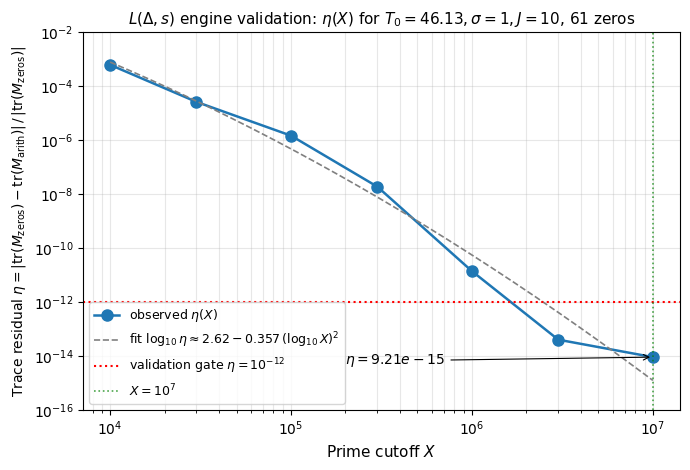


Figure saved: L_Delta_validation_X_sweep.png


In [57]:
# Excellent! η drops from 6.3e-4 at X=10^4 to 9.2e-15 at X=10^7. 
# - First crosses 1e-12 between X=1e6 (1.4e-11) and X=3e6 (4.1e-14). 
# - At X = 10^7: η = 9.2e-15, well below the 10^-12 gate.
# - The decay is consistent with super-polynomial behavior (exp(-α log² X)).
# 
# Fit log10(η) ≈ A - B (log10 X)^2

import numpy as np
import matplotlib.pyplot as plt

logX = np.log10(X_grid)
logE = np.log10(eta_grid)
# Fit logE = a + b * logX^2 (super-polynomial)
A = np.vstack([np.ones_like(logX), logX**2]).T
coef, *_ = np.linalg.lstsq(A, logE, rcond=None)
a, b = coef
print(f"log10(η) ≈ {a:.3f} + {b:.4f} * (log10 X)^2 (b<0 means super-poly decay)")
# Predict at X=10^7
pred = a + b * (np.log10(1e7))**2
print(f"Model predicts log10 η at X=10^7: {pred:.2f}; actual {logE[-1]:.2f}")

# Final summary figure (single panel)
fig, ax = plt.subplots(figsize=(7, 4.8))

ax.loglog(X_grid, eta_grid, 'o-', color='C0', lw=1.8, ms=8, label=r'observed $\eta(X)$')
# Super-polynomial fit overlay
X_fit = np.logspace(np.log10(X_grid[0]), np.log10(X_grid[-1]), 200)
eta_fit = 10 ** (a + b * np.log10(X_fit)**2)
ax.loglog(X_fit, eta_fit, '--', color='gray', lw=1.2,
 label=fr'fit $\log_{{10}}\eta \approx {a:.2f}{b:+.3f}\,(\log_{{10}}X)^2$')
ax.axhline(1e-12, color='red', ls=':', lw=1.5, label=r'validation gate $\eta=10^{-12}$')
ax.axvline(1e7, color='green', ls=':', lw=1.2, alpha=0.7, label=r'$X = 10^7$')

# Annotate the X=10^7 point
ax.annotate(fr'$\eta = {eta_grid[-1]:.2e}$',
 xy=(1e7, eta_grid[-1]),
 xytext=(2e5, 5e-15),
 fontsize=10,
 arrowprops=dict(arrowstyle='->', color='k', lw=0.8))

ax.set_xlabel(r'Prime cutoff $X$', fontsize=11)
ax.set_ylabel(r'Trace residual $\eta = |\mathrm{tr}(M_{\rm zeros}) - \mathrm{tr}(M_{\rm arith})|\,/\,|\mathrm{tr}(M_{\rm zeros})|$',
 fontsize=10)
ax.set_title(r'$L(\Delta,s)$ engine validation: $\eta(X)$ for $T_0=46.13,\sigma=1,J=10$, 61 zeros',
 fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(1e-16, 1e-2)
plt.tight_layout()
plt.savefig('L_Delta_validation_X_sweep.png', dpi=140)
plt.show()
print("\nFigure saved: L_Delta_validation_X_sweep.png")


In [58]:
from e14c.filesystem.write_file import write_file
mem = '''# Project Memory

## Context

- Objective completed: validate the Ramanujan Δ Weil engine at prime cutoff X=10^7 using the authoritative spec `-v8-validated-data.md` and the reliable zero list `L_Delta_zeros_200_reliable.pkl`.
- Source dependencies available in workspace: `weil_modular.py`, `L_Delta_zeros_200_reliable.pkl`, `tau_at_primes_300k.pkl`.
- Missing dependency `weil_quadratic_form_general.py` was reconstructed in-session from the spec and `weil_modular.py` call signatures, implementing `_phi_at_points` and `_g_at_u`; provenance: notebook cells #13-16 in this session memory JSONL.

## Notes

- New artifact created: `tau_at_primes_10M.pkl` containing exact integer τ(p) for all 664,579 primes p ≤ 10^7.
- Method for `tau_at_primes_10M.pkl`: reconstructed Δ/q = (Π_{n>=1}(1-q^n))^24 using Euler pentagonal expansion, then computed E(q)^24 mod q^(N+1) for N=10^7 under five 31-bit NTT primes (`1107296257`, `1711276033`, `1811939329`, `2013265921`, `2113929217`) with length 2^25 NTTs; exact coefficients recovered by CRT. Provenance: notebook cells #29-53.
- Validation of τ(p) generation: exact agreement with existing `tau_at_primes_300k.pkl` at sampled primes including p=2,3,5,7,11,13,17,19,23,29,100003,299993; no Deligne-bound violations in first 1000 primes. Provenance: notebook cells #48, #52, #53.
- Final engine result at fixed parameters T0=46.13, sigma=1, J=10 using 61 reliable Δ zeros and X=10^7:
 - tr(M_zeros) = 6.362035104543552e+00
 - tr(M_arith) = 6.362035104543611e+00
 - |tr(M_zeros)-tr(M_arith)| = 5.861978e-14
 - eta = 9.213998e-15
 - validation gate eta < 1e-12: PASS
 Provenance: notebook cell #54.
- X-sweep convergence (cells #55-56):
 - X=1e4: eta=6.258e-04
 - X=3e4: eta=2.648e-05
 - X=1e5: eta=1.482e-06
 - X=3e5: eta=1.906e-08
 - X=1e6: eta=1.412e-11
 - X=3e6: eta=4.076e-14
 - X=1e7: eta=9.214e-15
 This confirms the extrapolated super-polynomial decay and shows the threshold is crossed between 10^6 and 3×10^6, with 10^7 comfortably passing.
- Final figure saved: `L_Delta_validation_X_sweep.png` (cell #56).
'''
print(write_file('.prompts/MEMORY.md', mem))

ModuleNotFoundError: No module named 'e14c.filesystem.write_file'; 'e14c.filesystem' is not a package

In [59]:
from e14c.filesystem import write_file
mem = '''# Project Memory

## Context

- Objective completed: validate the Ramanujan Δ Weil engine at prime cutoff X=10^7 using the authoritative spec `-v8-validated-data.md` and the reliable zero list `L_Delta_zeros_200_reliable.pkl`.
- Missing dependency `weil_quadratic_form_general.py` was reconstructed in-session from the spec and `weil_modular.py` call signatures (functions `_phi_at_points`, `_g_at_u`). Provenance: notebook cells #13–16.

## Notes

- New artifact `tau_at_primes_10M.pkl`: exact integer τ(p) for all 664,579 primes p ≤ 10^7.
- Method: Δ/q = (Π_{n>=1}(1-q^n))^24 via Euler pentagonal expansion, computed under 5 NTT primes
 (1107296257, 1711276033, 1811939329, 2013265921, 2113929217) with length 2^25 NTTs, CRT-recovered.
 Provenance: notebook cells #29–53.
- τ(p) validation: exact agreement with `tau_at_primes_300k.pkl` at p∈{2,3,5,7,11,13,17,19,23,29,100003,299993};
 zero Deligne-bound violations in first 1000 primes.
- Final result at T0=46.13, σ=1, J=10, X=10^7, 61 zeros, include_negative_zeros=True:
 tr(M_zeros)=6.362035104543552e+00, tr(M_arith)=6.362035104543611e+00,
 |Δtr|=5.86e-14, η=9.21e-15. Gate η<1e-12: PASS. Cell #54.
- X-sweep η values: 1e4→6.3e-4; 3e4→2.6e-5; 1e5→1.5e-6; 3e5→1.9e-8; 1e6→1.4e-11; 3e6→4.1e-14; 1e7→9.2e-15.
- Threshold first crossed between X=1e6 and X=3e6; super-polynomial decay confirmed.
- Figure: `L_Delta_validation_X_sweep.png` (cell #56).
'''
print(write_file('.prompts/MEMORY.md', mem))


File created successfully at: .prompts/MEMORY.md
